In [1]:
import numpy as np
import torch
import random
import os
from latex_table_utils import format_table 
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)
os.environ['PYTHONHASHSEED'] = str(0)

In [2]:
only_1_species = True

In [3]:
import json
import pandas as pd
from sklearn.model_selection import train_test_split

with open("e2_results_hsn_test.json", "r") as f:
    e2_results = json.load(f)

df = pd.DataFrame(e2_results["HSN"]["0"]["data"]["raw_data"])
df = df[~df.isnull().any(axis=1)]
df["GT"] = df["gt"].apply(len)
train_valid, test = train_test_split(df, test_size=0.2)
train, valid = train_test_split(train_valid, test_size=0.2)
train.shape

import statsmodels.api as sm

X = sm.add_constant(train[['entropy', 'complexity', 'GT']])
ols_model = sm.OLS(train['loss'], X, M=sm.robust.norms.HuberT()).fit()
ols_model.summary()

/home/s.perry.543/egci_bioacoustic_shifts/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['M']
  warnings.warn(msg, ValueWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   loss   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     522.4
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          3.14e-221
Time:                        12:21:28   Log-Likelihood:                -293.95
No. Observations:                1277   AIC:                             595.9
Df Residuals:                    1273   BIC:                             616.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8662      0.025     34.779      0.000       0.817       0.915
entropy       -0.3230      0.046     -7.089      0.000      -0.412      -0.234
complexity    -0.0497      0.144     -0.345      0.730      -0.332       0.233
GT             0.5103      0.013     38.835      0.000       0.485       0.536
==============================================================================
Omnibus:                      778.436   Durbin-Watson:                   1.938
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8737.631
Skew:                           2.674   Prob(JB):                         0.00
Kurtosis:                      14.646   Cond. No.                         22.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [4]:
X = sm.add_constant(train[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity', 'acoustic_richness', 'bioacoustic_index', 'GT']])
Huber_model = sm.RLM(train['loss'], X, M=sm.robust.norms.HuberT()).fit()
Huber_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:                   loss   No. Observations:                 1277
Model:                            RLM   Df Residuals:                     1270
Method:                          IRLS   Df Model:                            6
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sat, 21 Mar 2026                                         
Time:                        12:21:28                                         
No. Iterations:                    50                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
entropy                -0.0587      0.008     -6.964      0.000      -0.075      -0.042
complexity              0.0238      0.027      0.873      0.383      -0.030       0.077
acoustic_complexity    -0.0027      0.000    -15.621      0.000      -0.003      -0.002
acoustic_diversity      0.0027      0.003      0.817      0.414      -0.004       0.009
acoustic_richness       1.4814      0.051     29.154      0.000       1.382       1.581
bioacoustic_index    2.922e-05   8.39e-06      3.483      0.000    1.28e-05    4.57e-05
GT                      0.3994      0.002    172.460      0.000       0.395       0.404
=======================================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

In [5]:
train["loss"].value_counts()

loss
0.693147    673
0.891977      3
1.039928      2
2.514157      2
2.535534      2
           ... 
0.763397      1
0.854840      1
1.058894      1
0.975800      1
1.125950      1
Name: count, Length: 575, dtype: int64

In [6]:
train[(train["GT"] == 0) & (train["loss"] < 0.7)   ] 

,path,offset_s,sr,gt,entropy,complexity,lag,acoustic_complexity,acoustic_diversity,acoustic_richness,bioacoustic_index,loss,GT
1030,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.069340,0.065804,256,295.222496,0.068819,1.0,910.451634,0.693147,0
837,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.871871,0.180371,256,293.789966,2.302576,1.0,660.598801,0.693147,0
232,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.674288,0.339496,256,294.610093,2.302010,1.0,601.208096,0.693147,0
1671,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.111120,0.097772,256,293.041675,2.106139,1.0,706.247165,0.693147,0
1070,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.641616,0.327711,256,291.671128,2.301451,1.0,642.706705,0.693147,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
978,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.065589,0.061387,256,292.198724,0.451960,1.0,1022.808444,0.693147,0
1860,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.813146,0.200800,256,292.191295,2.302575,1.0,538.869950,0.693147,0
1709,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.859805,0.184427,256,293.690244,2.302575,1.0,593.601993,0.693147,0
1454,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.775476,0.224454,256,299.541700,2.302546,1.0,952.028195,0.693147,0


In [7]:
X = sm.add_constant(train[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity', 'acoustic_richness', 'bioacoustic_index', 'GT']])
ols_model = sm.OLS(train['loss'], X, M=sm.robust.norms.HuberT()).fit()
ols_model.summary()

/home/s.perry.543/egci_bioacoustic_shifts/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:130: ValueWarning: unknown kwargs ['M']
  warnings.warn(msg, ValueWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   loss   R-squared:                       0.564
Model:                            OLS   Adj. R-squared:                  0.562
Method:                 Least Squares   F-statistic:                     273.4
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          1.31e-224
Time:                        12:21:28   Log-Likelihood:                -276.85
No. Observations:                1277   AIC:                             567.7
Df Residuals:                    1270   BIC:                             603.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
entropy                -0.3511      0.048     -7.240      0.000      -0.446      -0.256
complexity             -0.1100      0.157     -0.702      0.483      -0.417       0.197
acoustic_complexity    -0.0044      0.001     -4.398      0.000      -0.006      -0.002
acoustic_diversity      0.0535      0.019      2.821      0.005       0.016       0.091
acoustic_richness       1.9810      0.292      6.776      0.000       1.407       2.555
bioacoustic_index       0.0001   4.83e-05      2.472      0.014    2.46e-05       0.000
GT                      0.5239      0.013     39.315      0.000       0.498       0.550
==============================================================================
Omnibus:                      770.486   Durbin-Watson:                   1.943
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             8409.809
Skew:                           2.648   Prob(JB):                         0.00
Kurtosis:                      14.402   Cond. No.                     2.90e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.9e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [8]:
train["loss"].value_counts()

loss
0.693147    673
0.891977      3
1.039928      2
2.514157      2
2.535534      2
           ... 
0.763397      1
0.854840      1
1.058894      1
0.975800      1
1.125950      1
Name: count, Length: 575, dtype: int64

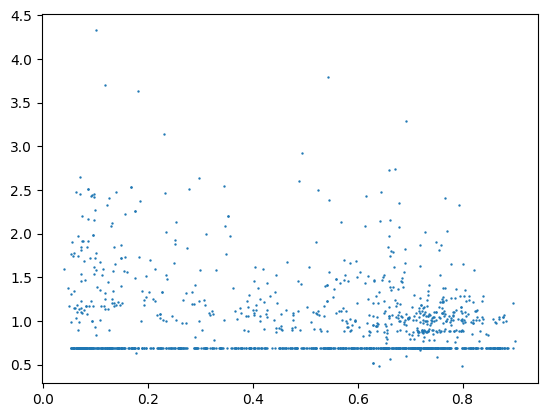

In [9]:
import matplotlib.pyplot as plt
plt.scatter(train["entropy"], train["loss"], s=0.5)

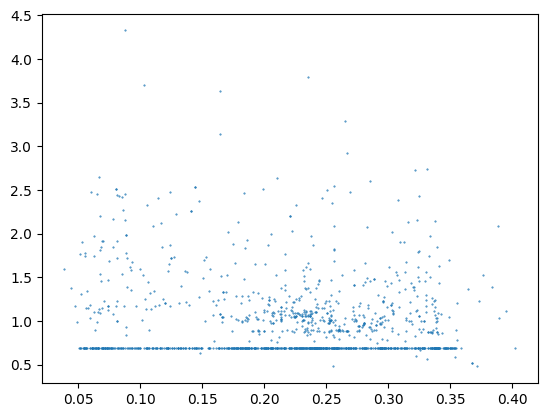

In [10]:
plt.scatter(train["complexity"], train["loss"], s=0.2)

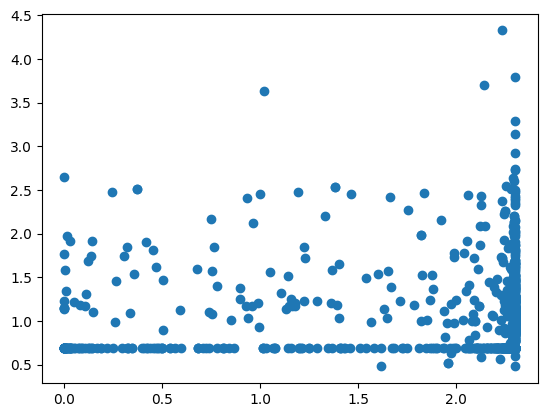

In [11]:
plt.scatter(train["acoustic_diversity"], train["loss"])

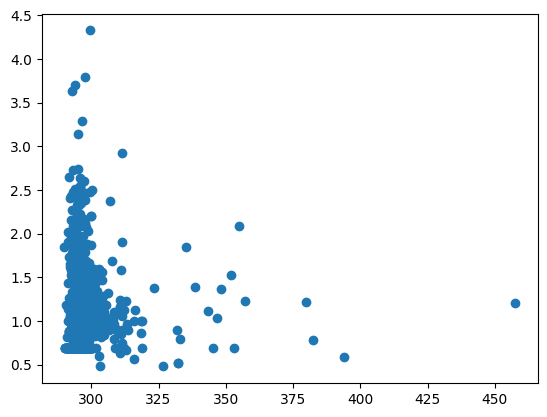

In [12]:
plt.scatter(train["acoustic_complexity"], train["loss"])

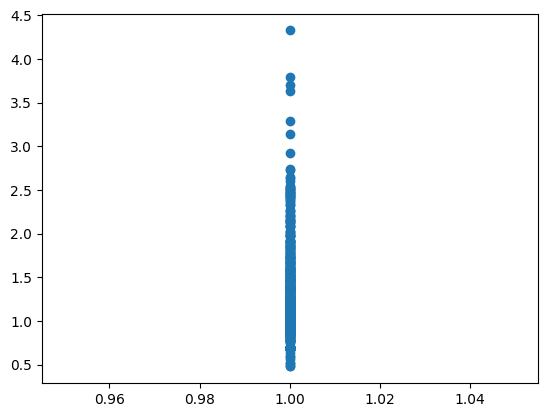

In [13]:
plt.scatter(train["acoustic_richness"], train["loss"])

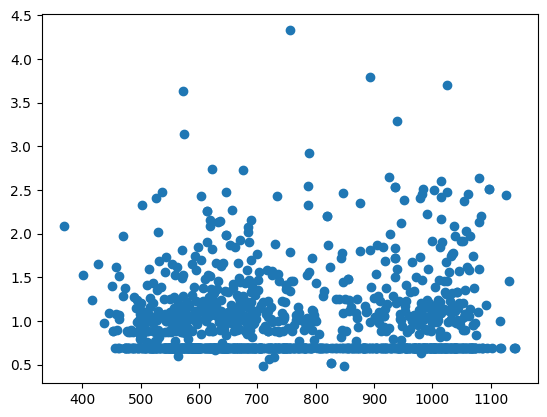

In [14]:
plt.scatter(train["bioacoustic_index"], train["loss"])

In [15]:
train_only_birds = train[train["GT"] > 0]

X = sm.add_constant(train[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']]) #'acoustic_richness', Seems to always be 1. That isn't useful
Huber_model = sm.RLM(train['loss'], X, M=sm.robust.norms.HuberT()).fit()
Huber_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:                   loss   No. Observations:                 1277
Model:                            RLM   Df Residuals:                     1270
Method:                          IRLS   Df Model:                            6
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sat, 21 Mar 2026                                         
Time:                        12:21:28                                         
No. Iterations:                    50                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.4814      0.051     29.154      0.000       1.382       1.581
entropy                -0.0587      0.008     -6.964      0.000      -0.075      -0.042
complexity              0.0238      0.027      0.873      0.383      -0.030       0.077
acoustic_complexity    -0.0027      0.000    -15.621      0.000      -0.003      -0.002
acoustic_diversity      0.0027      0.003      0.817      0.414      -0.004       0.009
bioacoustic_index    2.922e-05   8.39e-06      3.483      0.000    1.28e-05    4.57e-05
GT                      0.3994      0.002    172.460      0.000       0.395       0.404
=======================================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

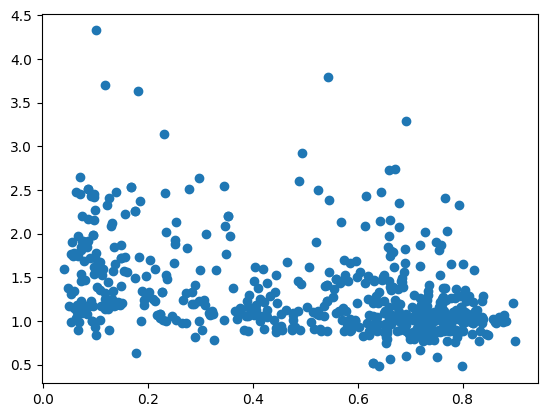

In [16]:
plt.scatter(train_only_birds["entropy"], train_only_birds["loss"])

# High level idea: we drew 100 2000-size samples from our population, we are going to see if we can identify the coeffs used here

In [17]:
entropies = []
complexities = []
for trial in e2_results["HSN"].keys():
    df = pd.DataFrame(e2_results["HSN"][trial]["data"]["raw_data"])
    df = df[~df.isnull().any(axis=1)]
    df["GT"] = df["gt"].apply(len)
    train_valid, test = train_test_split(df, test_size=0.2)
    train, valid = train_test_split(train_valid, test_size=0.2)

    X = sm.add_constant(train[['entropy', 'complexity', 'GT']])
    trial_model = sm.RLM(train['loss'], X, M=sm.robust.norms.HuberT()).fit()
    entropies.append(trial_model.params["entropy"])
    complexities.append(trial_model.params["complexity"])




# Normalization Experiments

In [18]:
train[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']]

,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index,GT
1934,0.677577,0.235894,296.414699,2.302559,1016.498359,1
568,0.546162,0.246543,295.718825,2.302509,1045.089347,2
378,0.609530,0.308317,295.614587,2.299794,543.727924,1
1630,0.843753,0.191499,292.641259,2.302570,730.353773,0
1527,0.118735,0.100490,294.959923,2.278823,1006.344691,0
...,...,...,...,...,...,...
269,0.180593,0.148154,297.727635,1.407940,978.343040,0
1651,0.664234,0.328495,295.373722,2.301698,748.512628,0
947,0.474256,0.295472,292.046761,2.299540,567.869585,0
164,0.634481,0.294651,303.824503,2.297878,498.136311,1


In [19]:
train_norm = train[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']].apply(lambda col: (col - col.mean()) / (col.std()))
train_norm

,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index,GT
1934,0.664371,0.144696,-0.088329,0.449247,1.324622,0.762497
568,0.162170,0.273247,-0.160169,0.449171,1.478237,2.330466
378,0.404330,1.018981,-0.170930,0.444963,-1.215490,0.762497
1630,1.299415,-0.391241,-0.477887,0.449264,-0.212782,-0.805472
1527,-1.471249,-1.489899,-0.238516,0.412467,1.270068,-0.805472
...,...,...,...,...,...,...
269,-1.234855,-0.914503,0.047214,-0.937003,1.119621,-0.805472
1651,0.613383,1.262572,-0.195796,0.447914,-0.115218,-0.805472
947,-0.112620,0.863925,-0.539261,0.444569,-1.085781,-0.805472
164,0.499680,0.854015,0.676635,0.441995,-1.460446,0.762497


In [20]:
train_norm.mean(), train_norm.std()

(entropy               -6.676987e-17
 complexity             1.391039e-17
 acoustic_complexity   -4.470799e-15
 acoustic_diversity     1.557964e-16
 bioacoustic_index     -5.007741e-16
 GT                    -3.894909e-17
 dtype: float64,
 entropy                1.0
 complexity             1.0
 acoustic_complexity    1.0
 acoustic_diversity     1.0
 bioacoustic_index      1.0
 GT                     1.0
 dtype: float64)

In [21]:
X = sm.add_constant(train_norm) #'acoustic_richness', Seems to always be 1. That isn't useful
Huber_model = sm.RLM(train['loss'], X, M=sm.robust.norms.HuberT()).fit()
Huber_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:                   loss   No. Observations:                 1277
Model:                            RLM   Df Residuals:                     1270
Method:                          IRLS   Df Model:                            6
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sat, 21 Mar 2026                                         
Time:                        12:21:29                                         
No. Iterations:                    50                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.8975      0.001    848.134      0.000       0.895       0.900
entropy                -0.0096      0.002     -6.014      0.000      -0.013      -0.006
complexity             -0.0022      0.002     -1.399      0.162      -0.005       0.001
acoustic_complexity    -0.0226      0.001    -20.295      0.000      -0.025      -0.020
acoustic_diversity      0.0028      0.001      1.889      0.059      -0.000       0.006
bioacoustic_index       0.0027      0.001      2.382      0.017       0.000       0.005
GT                      0.2608      0.001    238.452      0.000       0.259       0.263
=======================================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

In [22]:
X = sm.add_constant(train_norm) #'acoustic_richness', Seems to always be 1. That isn't useful
ols_model = sm.OLS(train['loss'], X).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   loss   R-squared:                       0.585
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     297.9
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          3.77e-238
Time:                        12:21:30   Log-Likelihood:                -308.59
No. Observations:                1277   AIC:                             631.2
Df Residuals:                    1270   BIC:                             667.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.9721      0.009    112.437      0.000       0.955       0.989
entropy                -0.0866      0.013     -6.673      0.000      -0.112      -0.061
complexity             -0.0237      0.013     -1.867      0.062      -0.049       0.001
acoustic_complexity    -0.0516      0.009     -5.663      0.000      -0.069      -0.034
acoustic_diversity      0.0284      0.012      2.336      0.020       0.005       0.052
bioacoustic_index       0.0214      0.009      2.295      0.022       0.003       0.040
GT                      0.3626      0.009     40.587      0.000       0.345       0.380
==============================================================================
Omnibus:                      769.671   Durbin-Watson:                   1.984
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9436.605
Skew:                           2.595   Prob(JB):                         0.00
Kurtosis:                      15.265   Cond. No.                         2.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Hypothesis testing



In [23]:
train

,path,offset_s,sr,gt,entropy,complexity,lag,acoustic_complexity,acoustic_diversity,acoustic_richness,bioacoustic_index,loss,GT
1934,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[4],0.677577,0.235894,256,296.414699,2.302559,1.0,1016.498359,1.053684,1
568,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,"[0, 4]",0.546162,0.246543,256,295.718825,2.302509,1.0,1045.089347,1.545821,2
378,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[12],0.609530,0.308317,256,295.614587,2.299794,1.0,543.727924,0.911821,1
1630,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.843753,0.191499,256,292.641259,2.302570,1.0,730.353773,0.693147,0
1527,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.118735,0.100490,256,294.959923,2.278823,1.0,1006.344691,0.693147,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
269,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.180593,0.148154,256,297.727635,1.407940,1.0,978.343040,0.693147,0
1651,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.664234,0.328495,256,295.373722,2.301698,1.0,748.512628,0.693147,0
947,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[],0.474256,0.295472,256,292.046761,2.299540,1.0,567.869585,0.693147,0
164,/home/s.perry.543/.cache/huggingface/datasets/...,0,32000,[1],0.634481,0.294651,256,303.824503,2.297878,1.0,498.136311,0.866958,1


In [24]:
train_data = train[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT', 'loss']]

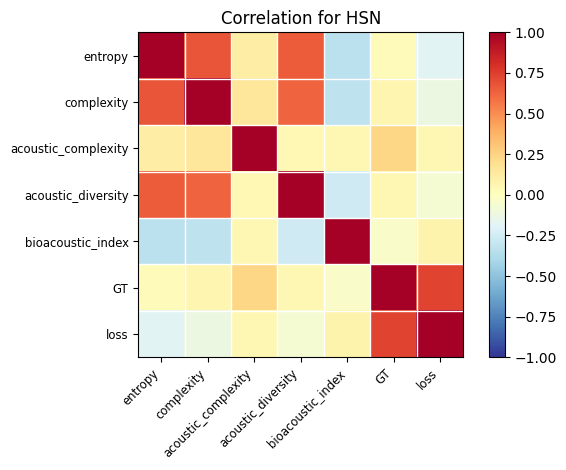

In [25]:
import numpy as np
import statsmodels.graphics.api as smg
corr_matrix = np.corrcoef(train_data.T)
smg.plot_corr(corr_matrix, xnames=train_data.columns, normcolor=True)
plt.title("Correlation for HSN")
plt.show()

Step Back: I want to show that Acoustics Complexities Indcies have relationships to the Loss

Larger Step Back: EGCI can be used to understand domain shift. 

Experiment 1 shows focal and soundscapes can be understand under the lense of ACIs
Experiment 2 shows that ACIs can help us understand what models might be doing with soundscape recordings

=> That ACIs have an understated role in helping us potentially unravel domain shift, and are more interpertable than model embeddings. Paper does not make a claim to crack that puzzle yet, but this could be a promising way of studying the problem. 


Experiment 3: Todo in another paper but maybe what is the relationship between Model Performance and Domain Shift as told by ACIs?

# Out of 100 Experiments each with a diffrent sample of 2000 5 second segments, we consider the following experiments

Based on scatter plots, most relationships appear linear, we will use person correlation for all independent variables

## Experiment 2a) Loss has correlatations with X variable

TODO More regions actually perform hypothesis test
Null: Not correlated
Alt: Is correlated

In [26]:
import scipy
# Do for each and all regions?
trials = []
for trial in e2_results["HSN"].keys():
    df = pd.DataFrame(e2_results["HSN"][trial]["data"]["raw_data"])
    df = df[~df.isnull().any(axis=1)]
    df["GT"] = df["gt"].apply(len)
    df = df[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT', 'loss']]
    corr = df[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']].apply(lambda x: scipy.stats.pearsonr(x, df["loss"])[0])
    print(df[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']].apply(lambda x: scipy.stats.pearsonr(x, df["loss"])[1]))

    trials.append(corr)
    # Compute person correlation for each variable
correlations = pd.concat(trials, axis=1).T
correlations

entropy                4.531458e-12
complexity             1.989231e-08
acoustic_complexity    8.383250e-04
acoustic_diversity     6.082809e-03
bioacoustic_index      1.414464e-03
GT                     0.000000e+00
dtype: float64
entropy                 6.591240e-10
complexity              8.849798e-06
acoustic_complexity     5.461724e-04
acoustic_diversity      4.122493e-03
bioacoustic_index       5.210295e-02
GT                     3.359608e-313
dtype: float64
entropy                5.419617e-11
complexity             1.768164e-06
acoustic_complexity    2.311396e-02
acoustic_diversity     2.769153e-04
bioacoustic_index      7.291336e-03
GT                     0.000000e+00
dtype: float64
entropy                 3.101645e-11
complexity              8.911066e-04
acoustic_complexity     5.965752e-03
acoustic_diversity      8.615051e-03
bioacoustic_index       1.963714e-03
GT                     1.854683e-314
dtype: float64
entropy                 3.044326e-15
complexity              2.3

,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index,GT
0,-0.154013,-0.125187,0.074679,-0.061368,0.071375,0.725529
1,-0.137657,-0.099276,0.077311,-0.064183,0.043481,0.715719
2,-0.146076,-0.106687,0.050830,-0.081280,0.060027,0.738336
3,-0.147935,-0.074319,0.061526,-0.058785,0.069251,0.716707
4,-0.175193,-0.132986,0.042839,-0.084900,0.081633,0.715672
...,...,...,...,...,...,...
95,-0.165331,-0.114796,0.041037,-0.056741,0.084407,0.740330
96,-0.165870,-0.131906,0.020555,-0.112862,0.052015,0.707343
97,-0.170816,-0.123361,0.030111,-0.089080,0.085209,0.708926
98,-0.195418,-0.149877,0.037387,-0.104275,0.052177,0.699631


In [27]:
import scipy
# Do for each and all regions?
trials = []
for trial in e2_results["HSN"].keys():
    df = pd.DataFrame(e2_results["HSN"][trial]["data"]["raw_data"])
    df = df[~df.isnull().any(axis=1)]
    df["GT"] = df["gt"].apply(len)
    df = df[df["GT"] > 0]
    df = df[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT', 'loss']]
    corr = df[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']].apply(lambda x: scipy.stats.pearsonr(x, df["loss"])[0])
    print(df[['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']].apply(lambda x: scipy.stats.pearsonr(x, df["loss"])[1]))
    trials.append(corr)
    # Compute person correlation for each variable
correlations = pd.concat(trials, axis=1).T
correlations

entropy                3.017407e-37
complexity             1.143445e-19
acoustic_complexity    1.097918e-03
acoustic_diversity     1.546126e-11
bioacoustic_index      1.151062e-07
GT                     3.131974e-34
dtype: float64
entropy                3.239384e-23
complexity             9.491345e-17
acoustic_complexity    5.048879e-03
acoustic_diversity     7.424957e-09
bioacoustic_index      5.954822e-06
GT                     2.347436e-27
dtype: float64
entropy                1.268978e-27
complexity             1.873851e-17
acoustic_complexity    3.946951e-03
acoustic_diversity     2.420660e-09
bioacoustic_index      1.959077e-05
GT                     6.918234e-45
dtype: float64
entropy                7.650763e-32
complexity             9.981832e-17
acoustic_complexity    2.642200e-02
acoustic_diversity     3.126817e-08
bioacoustic_index      9.848688e-08
GT                     3.354958e-31
dtype: float64
entropy                1.199140e-35
complexity             2.326259e-23
acou

,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index,GT
0,-0.402424,-0.292525,-0.107276,-0.219549,0.173399,0.386373
1,-0.328346,-0.277264,-0.095201,-0.194843,0.153180,0.356538
2,-0.354266,-0.280109,-0.096690,-0.198624,0.142822,0.447460
3,-0.384601,-0.277381,-0.075526,-0.186886,0.180089,0.380802
4,-0.401292,-0.325660,-0.093271,-0.233245,0.234596,0.406624
...,...,...,...,...,...,...
95,-0.378707,-0.287459,-0.113890,-0.182964,0.156419,0.399453
96,-0.374169,-0.303265,-0.119001,-0.257018,0.129999,0.385164
97,-0.394878,-0.306664,-0.117180,-0.225363,0.191373,0.351180
98,-0.406916,-0.300121,-0.083723,-0.217733,0.157424,0.283652


# Experiment 2c: What is the best feature for predicting loss from ACIs?

Given the features we have been studying, lets do feature selection to create a good model on validation, then save test performance
Also record which features we used each trial. The more often we use each feature, the more important it maybe for predicting model loss


Note that there is good evidence to suggest that linear regression doesn't make sense here. So lets cut out all the worry about what assumptions hold by changing the model we use. 

In [28]:
from itertools import combinations
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error

features = ['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']
feature_importances = []
for trial in e2_results["HSN"].keys():
    df = pd.DataFrame(e2_results["HSN"][trial]["data"]["raw_data"])
    df = df[~df.isnull().any(axis=1)]
    df["GT"] = df["gt"].apply(len)
    train_valid, test = train_test_split(df, test_size=0.2)
    train, valid = train_test_split(train_valid, test_size=0.2)
    pipe = make_pipeline(StandardScaler(), RandomForestRegressor())
    
    rfr = pipe.fit(train[features], train["loss"])
   
    print(rfr.score(valid[features], valid["loss"]))
    print(root_mean_squared_error(valid["loss"], pipe.predict(valid[features])))
    feature_importance = pd.Series(index=features, data=rfr.steps[-1][-1].feature_importances_)
    feature_importances.append(feature_importance)

    # X = sm.add_constant(train[['entropy', 'complexity', 'GT']])
    # trial_model = sm.RLM(train['loss'], X, M=sm.robust.norms.HuberT()).fit()

pd.concat(feature_importances, axis=1).T
    

0.5898153134965929
0.27622617509852804
0.6034490255577992
0.2583526186158512
0.6110708789974286
0.28898686974394283
0.6569000223550878
0.26567567047112794
0.6513421466962046
0.27209968481268487
0.5943403720426504
0.29932171044324196
0.5546915455249626
0.2782850074451222
0.5931138111234528
0.30869788769064166
0.5711839374770351
0.3275136046785133
0.7165458089280734
0.24153981775195496
0.6098460736210363
0.2601804745271103
0.6182999004717957
0.3269627540515131
0.5430564666238813
0.29724700572653323
0.6241867780946986
0.2762732303055343
0.7067221739744812
0.23488404336556526
0.6338431850613437
0.3001693069398673
0.6015035226627703
0.3307628462875377
0.6590624208723913
0.24484435965321907
0.49755891056745094
0.24882285776641483
0.5584433669613065
0.3022020190161425
0.6736496287555694
0.2497397428508159
0.48800832211665646
0.23769950449013044
0.5927580985207402
0.31466483107378773
0.6162797529326796
0.3170179741983299
0.6613225774430791
0.2842290473864515
0.7172809235749038
0.23867504018427

,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index,GT
0,0.142846,0.103583,0.084338,0.077406,0.072961,0.518865
1,0.140876,0.077326,0.115195,0.062610,0.086449,0.517544
2,0.132454,0.085581,0.091928,0.069424,0.060236,0.560377
3,0.156662,0.072401,0.119143,0.060386,0.080960,0.510448
4,0.159129,0.078450,0.082339,0.071832,0.083941,0.524309
...,...,...,...,...,...,...
95,0.150764,0.061052,0.089041,0.066843,0.069080,0.563220
96,0.112283,0.126638,0.103878,0.066935,0.058331,0.531936
97,0.093030,0.151499,0.124172,0.067431,0.062464,0.501404
98,0.178730,0.084253,0.074440,0.083166,0.072355,0.507056


In [29]:
pd.concat(feature_importances, axis=1).T

,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index,GT
0,0.142846,0.103583,0.084338,0.077406,0.072961,0.518865
1,0.140876,0.077326,0.115195,0.062610,0.086449,0.517544
2,0.132454,0.085581,0.091928,0.069424,0.060236,0.560377
3,0.156662,0.072401,0.119143,0.060386,0.080960,0.510448
4,0.159129,0.078450,0.082339,0.071832,0.083941,0.524309
...,...,...,...,...,...,...
95,0.150764,0.061052,0.089041,0.066843,0.069080,0.563220
96,0.112283,0.126638,0.103878,0.066935,0.058331,0.531936
97,0.093030,0.151499,0.124172,0.067431,0.062464,0.501404
98,0.178730,0.084253,0.074440,0.083166,0.072355,0.507056


In [30]:
rfr.steps[-1][-1].feature_importances_

features

['entropy',
 'complexity',
 'acoustic_complexity',
 'acoustic_diversity',
 'bioacoustic_index',
 'GT']

In [31]:
test = RandomForestRegressor().fit(train[features], train["loss"])
test.feature_importances_

array([0.12614864, 0.08390748, 0.10666924, 0.06415541, 0.05575557,
       0.56336366])

Note: Non bird has a very simliar loss

In [32]:
features = ['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']
feature_importances = []
for trial in e2_results["HSN"].keys():
    df = pd.DataFrame(e2_results["HSN"][trial]["data"]["raw_data"])
    df = df[~df.isnull().any(axis=1)]
    df["GT"] = df["gt"].apply(len)
    df = df[df["GT"] > 0]
    train_valid, test = train_test_split(df, test_size=0.2)
    train, valid = train_test_split(train_valid, test_size=0.2)
    pipe = make_pipeline(StandardScaler(), RandomForestRegressor())
    
    rfr = pipe.fit(train[features], train["loss"])
   
    print(rfr.score(valid[features], valid["loss"]))
    print(root_mean_squared_error(valid["loss"], pipe.predict(valid[features])))
    feature_importance = pd.Series(index=features, data=rfr.steps[-1][-1].feature_importances_)
    feature_importances.append(feature_importance)

    # X = sm.add_constant(train[['entropy', 'complexity', 'GT']])
    # trial_model = sm.RLM(train['loss'], X, M=sm.robust.norms.HuberT()).fit()

pd.concat(feature_importances, axis=1).T

0.3479318751209325
0.37256108558069595
0.3127348080038107
0.3920671984922825
0.44072877728062354
0.5009052437549032
0.2543656956064647
0.3998183768886917
0.4318055419889767
0.3647418951056224
0.4255613535652891
0.46718255730125013
0.2986554644806967
0.5137662268785962
0.24024340178388104
0.5487978714826163
0.3230301119334318
0.40588590407669073
0.2643754109760428
0.4568793266786574
0.5224410002066597
0.34517604566956395
0.31732797060024354
0.3743903942899321
0.10747768015353665
0.39520342969047484
0.31070661825276313
0.3619580934361127
0.3353493306117298
0.4040477896634415
0.16117638309679483
0.4441759765803746
0.34486912023202154
0.37652456126958533
0.20479129954147168
0.5039066592020436
0.3709528076857137
0.43484967370870864
0.23939526831835345
0.4069510995953194
0.36840394224732476
0.3971214075360193
0.30559310176092236
0.4014684968978324
0.16525282558152277
0.33869116811715105
0.19804328574437535
0.3835340408203381
0.4642574596496518
0.39331310340160264
0.4306197893514013
0.3042654

,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index,GT
0,0.308754,0.122116,0.174726,0.122294,0.168140,0.103969
1,0.229368,0.127343,0.183452,0.134973,0.182159,0.142705
2,0.242304,0.150128,0.180064,0.132727,0.117964,0.176814
3,0.293385,0.109671,0.148371,0.131113,0.153601,0.163860
4,0.173730,0.163671,0.152033,0.105229,0.125578,0.279759
...,...,...,...,...,...,...
95,0.269500,0.121983,0.173781,0.112772,0.140052,0.181912
96,0.227484,0.188853,0.211111,0.095645,0.110995,0.165913
97,0.160040,0.259957,0.201988,0.103660,0.115003,0.159353
98,0.296694,0.135717,0.157555,0.171630,0.126422,0.111982


array([[<Axes: title={'center': 'entropy'}>,
        <Axes: title={'center': 'complexity'}>],
       [<Axes: title={'center': 'acoustic_complexity'}>,
        <Axes: title={'center': 'acoustic_diversity'}>],
       [<Axes: title={'center': 'bioacoustic_index'}>,
        <Axes: title={'center': 'GT'}>]], dtype=object)

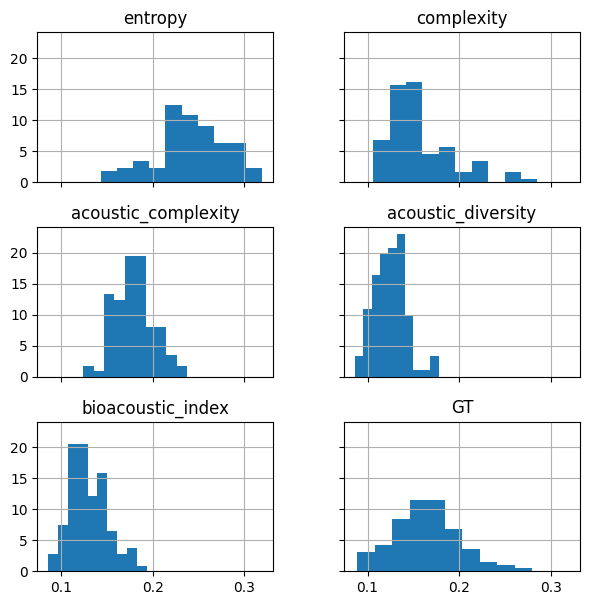

In [33]:

pd.concat(feature_importances, axis=1).T.hist(figsize=(7, 7), sharex=True, sharey=True, density=True)

In [34]:
pd.concat(feature_importances, axis=1).T.sum(axis=1).value_counts()

1.0    83
1.0    10
1.0     5
1.0     1
1.0     1
Name: count, dtype: int64

# TODO
- Design the hypothesis test for these datasets
- Demonstrate this works
- Add more indices later?


# Explore Permutation Importance

In [35]:
from sklearn.inspection import permutation_importance


features = ['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']
feature_importances = []




for trial in e2_results["HSN"].keys():
    df = pd.DataFrame(e2_results["HSN"][trial]["data"]["raw_data"])
    df = df[~df.isnull().any(axis=1)]
    df["GT"] = df["gt"].apply(len)
    df = df[df["GT"] > 0]
    train_valid, test = train_test_split(df, test_size=0.2)
    train, valid = train_test_split(train_valid, test_size=0.2)
    pipe = make_pipeline(StandardScaler(), RandomForestRegressor())
    
    rfr = pipe.fit(train[features], train["loss"])
   

    result = permutation_importance(
        rfr, valid[features], valid["loss"], n_repeats=1000, random_state=42, n_jobs=2
    )

    
    print(result)
    # print(root_mean_squared_error(valid["loss"], pipe.predict(valid[features])))
    # feature_importance = pd.Series(index=features, data=rfr.steps[-1][-1].feature_importances_)
    feature_importances.append(result["importances_mean"])
    break
1 - (result["importances"] > 0).mean(axis=1), features

{'importances_mean': array([0.7585551 , 0.05202525, 0.22852251, 0.1011056 , 0.05041532,
       0.38038891]), 'importances_std': array([0.13252078, 0.03211508, 0.06680836, 0.03739406, 0.03506285,
       0.10730502]), 'importances': array([[0.63003956, 0.60836765, 0.77310966, ..., 0.91747822, 0.76671685,
        0.47222523],
       [0.01856393, 0.02956945, 0.11063162, ..., 0.02267685, 0.06869673,
        0.05551966],
       [0.18996181, 0.23951385, 0.21079873, ..., 0.31915338, 0.25849475,
        0.16561511],
       [0.13255151, 0.06731151, 0.07309489, ..., 0.12439645, 0.12981799,
        0.14158317],
       [0.02728383, 0.04041873, 0.06228991, ..., 0.10114402, 0.08372133,
        0.03670803],
       [0.30147721, 0.44136739, 0.41413205, ..., 0.31570577, 0.17515926,
        0.46283399]])}


(array([0.   , 0.051, 0.   , 0.005, 0.064, 0.   ]),
 ['entropy',
  'complexity',
  'acoustic_complexity',
  'acoustic_diversity',
  'bioacoustic_index',
  'GT'])

In [36]:

features = ['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']
feature_importances = []
for trial in e2_results["HSN"].keys():
    df = pd.DataFrame(e2_results["HSN"][trial]["data"]["raw_data"])
    df = df[~df.isnull().any(axis=1)]
    df["GT"] = df["gt"].apply(len)
    df = df[df["GT"] > 0]
    train_valid, test = train_test_split(df, test_size=0.2)
    train, valid = train_test_split(train_valid, test_size=0.2)
    pipe = make_pipeline(StandardScaler(), RandomForestRegressor())
    
    rfr = pipe.fit(train[features], train["loss"])
   

    result = permutation_importance(
        rfr, valid[features], valid["loss"], n_repeats=100, random_state=42, n_jobs=5
    )


    # print(root_mean_squared_error(valid["loss"], pipe.predict(valid[features])))
    # feature_importance = pd.Series(index=features, data=rfr.steps[-1][-1].feature_importances_)
    feature_importances.append(result["importances_mean"])

array([[<Axes: title={'center': 'entropy'}>,
        <Axes: title={'center': 'complexity'}>],
       [<Axes: title={'center': 'acoustic_complexity'}>,
        <Axes: title={'center': 'acoustic_diversity'}>],
       [<Axes: title={'center': 'bioacoustic_index'}>,
        <Axes: title={'center': 'GT'}>]], dtype=object)

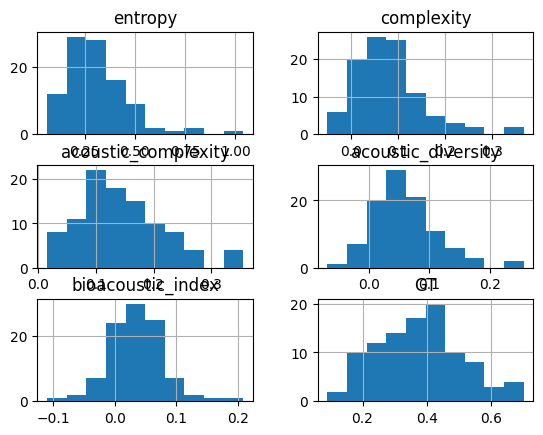

In [37]:
feature_importances

pd.DataFrame(feature_importances, columns = features).hist()

In [38]:
1 - (pd.DataFrame(feature_importances, columns = features) > 0).mean()

entropy                0.00
complexity             0.10
acoustic_complexity    0.00
acoustic_diversity     0.12
bioacoustic_index      0.21
GT                     0.00
dtype: float64

# Putting Everything Together

In [39]:
import statsmodels.stats.api as sms
from sklearn.inspection import permutation_importance
from itertools import combinations
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error
import json
import pandas as pd
from sklearn.model_selection import train_test_split

def run_experiment(df, features):
    train_valid, test = train_test_split(df, test_size=0.2)
    train, valid = train_test_split(train_valid, test_size=0.2)
    pipe = make_pipeline(StandardScaler(), RandomForestRegressor()) 
    rfr = pipe.fit(train[features], train["loss"])
   
    permuate_results = permutation_importance(
        rfr, valid[features], valid["loss"], n_repeats=100, random_state=42, n_jobs=5
    )

    corr = valid[features].apply(lambda x: scipy.stats.pearsonr(x, valid["loss"]))

    if "GT" in features:
        numSpeciesCorr = valid[features].apply(lambda x: scipy.stats.pearsonr(x, valid["GT"]))

    else: #Used to make rest of script easier, in this case ignore output
        numSpeciesCorr = corr
    
                    #Standard Scaling
    print(train[features].isnull().sum())
    print(train[features].apply(lambda x: (x - x.mean()) / x.std(), axis=0).isnull().sum())
    try:
        X = sm.add_constant(train[features].apply(lambda x: (x - x.mean()) / x.std(), axis=0))
        ols_model = sm.OLS(train['loss'], X).fit()
        # ols_test = sms.linear_harvey_collier(ols_model)

        Huber_model = sm.RLM(train['loss'], X, M=sm.robust.norms.HuberT()).fit()
        # Huber_test = sms.linear_harvey_collier(Huber_model)


        # score = rfr.score(test[features], test["loss"])
    except Exception as e:
        print(e)
        ols_model = None
        Huber_model = None

    return permuate_results, corr, ols_model, Huber_model, numSpeciesCorr

features = ['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']
feature_importances = []
for trial in e2_results["HSN"].keys():
    df = pd.DataFrame(e2_results["HSN"][trial]["data"]["raw_data"])
    df = df[~df.isnull().any(axis=1)]
    df["GT"] = df["gt"].apply(len)
    
    all_data = run_experiment(df, features)
    
    df = df[df["GT"] > 0]
    
    only_birds_data = run_experiment(df, features)
    break

entropy                0
complexity             0
acoustic_complexity    0
acoustic_diversity     0
bioacoustic_index      0
GT                     0
dtype: int64
entropy                0
complexity             0
acoustic_complexity    0
acoustic_diversity     0
bioacoustic_index      0
GT                     0
dtype: int64
entropy                0
complexity             0
acoustic_complexity    0
acoustic_diversity     0
bioacoustic_index      0
GT                     0
dtype: int64
entropy                0
complexity             0
acoustic_complexity    0
acoustic_diversity     0
bioacoustic_index      0
GT                     0
dtype: int64


In [40]:
test = df[features].apply(lambda x: (x - x.mean()) / x.std(), axis=0)
test["entropy"].mean(), test["entropy"].std()

(np.float64(2.6173838587045943e-16), np.float64(1.0))

In [41]:
test.isnull().sum()

entropy                0
complexity             0
acoustic_complexity    0
acoustic_diversity     0
bioacoustic_index      0
GT                     0
dtype: int64

#### Correlation Result

In [42]:
all_data[1], only_birds_data[1]

(    entropy  complexity  acoustic_complexity  acoustic_diversity  \
 0 -0.054921    0.033282             0.119147            0.072825   
 1  0.327405    0.553042             0.033121            0.193817   
 
    bioacoustic_index            GT  
 0           0.036793  7.360464e-01  
 1           0.511941  7.861108e-56  ,
     entropy  complexity  acoustic_complexity  acoustic_diversity  \
 0 -0.352585   -0.247244            -0.070036           -0.107815   
 1  0.000011    0.002449             0.397641            0.192130   
 
    bioacoustic_index            GT  
 0           0.240366  3.941874e-01  
 1           0.003254  7.157195e-07  )

#### Permuation Result

In [43]:
1 - (all_data[0]["importances"] > 0).mean(axis=1), 1 - (only_birds_data[0]["importances"] > 0).mean(axis=1)

(array([0.  , 0.01, 0.04, 0.12, 0.32, 0.  ]),
 array([0.  , 0.  , 0.01, 0.13, 0.02, 0.  ]))

#### Linear Regression Results (If Relevant)

In [44]:
only_birds_data[2].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   loss   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                  0.303
Method:                 Least Squares   F-statistic:                     43.74
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           3.72e-44
Time:                        12:23:48   Log-Likelihood:                -291.21
No. Observations:                 590   AIC:                             596.4
Df Residuals:                     583   BIC:                             627.1
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.2701      0.016     77.366      0.000       1.238       1.302
entropy                -0.2086      0.026     -8.093      0.000      -0.259      -0.158
complexity             -0.0083      0.026     -0.319      0.750      -0.059       0.043
acoustic_complexity    -0.0430      0.017     -2.504      0.013      -0.077      -0.009
acoustic_diversity      0.0457      0.024      1.923      0.055      -0.001       0.092
bioacoustic_index       0.0077      0.018      0.426      0.671      -0.028       0.043
GT                      0.1790      0.017     10.825      0.000       0.147       0.212
==============================================================================
Omnibus:                      255.713   Durbin-Watson:                   1.883
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1327.043
Skew:                           1.892   Prob(JB):                    6.86e-289
Kurtosis:                       9.298   Cond. No.                         3.07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [45]:
only_birds_data[3].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                    Robust linear Model Regression Results                    
==============================================================================
Dep. Variable:                   loss   No. Observations:                  590
Model:                            RLM   Df Residuals:                      583
Method:                          IRLS   Df Model:                            6
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sat, 21 Mar 2026                                         
Time:                        12:23:48                                         
No. Iterations:                    50                                         
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.1975      0.011    108.379      0.000       1.176       1.219
entropy                -0.1531      0.017     -8.822      0.000      -0.187      -0.119
complexity             -0.0132      0.017     -0.760      0.448      -0.047       0.021
acoustic_complexity    -0.0400      0.012     -3.459      0.001      -0.063      -0.017
acoustic_diversity      0.0273      0.016      1.708      0.088      -0.004       0.059
bioacoustic_index       0.0118      0.012      0.976      0.329      -0.012       0.036
GT                      0.1417      0.011     12.726      0.000       0.120       0.163
=======================================================================================

If the model instance has been used for another fit with different fit parameters, then the fit options might not be the correct ones anymore .
"""

# All Experiments Results over All Regions

In [46]:
if not only_1_species:
    with open("e2_results_done.json", mode="r") as f:
        other_regions = json.load(f) 

    with open("e2_results_SSW.json", mode="r") as f:
        ssw_data = json.load(f) 

    all_regions = other_regions
    all_regions["HSN"] = e2_results["HSN"]
    all_regions["SSW"] = ssw_data["SSW"]

else:
    with open("e2_results_True.json", "r") as f:
        all_regions = json.load(f)


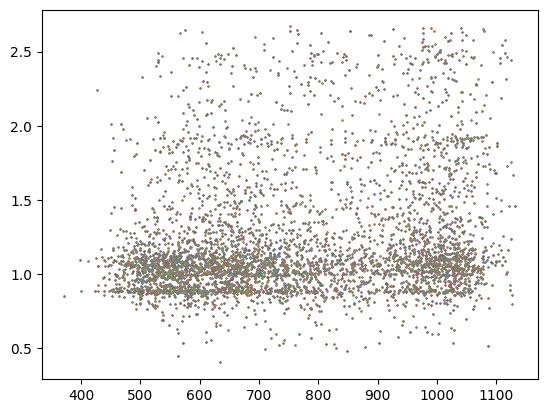

In [47]:
region = "HSN"
for trial in all_regions[region].keys():
    df = pd.DataFrame(all_regions[region][trial]["data"]["raw_data"])
    df = df[~df.isnull().any(axis=1)]
    df["GT"] = df["gt"].apply(len)

    plt.scatter(df["bioacoustic_index"], df["loss"], s=0.01)

In [48]:
# other_regions.keys()

In [49]:
e2_results.keys()

dict_keys(['HSN'])

In [50]:
trial

'99'

In [51]:

def experiment_per_region(region, disable_no_bird=False):
    print(region)
    features = ['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']
    feature_importances = []
    # for trial in e2_results["HSN"].keys():
    df = pd.DataFrame(all_regions[region][trial]["data"]["raw_data"])
    df = df[~df.isnull().any(axis=1)]
    df["GT"] = df["gt"].apply(len)

    
    
    if not disable_no_bird:
        all_data = run_experiment(df, features)

        bird_df = df[df["GT"] > 0]

        only_birds_data = run_experiment(bird_df, features)

   
        no_df = df[df["GT"] == 0]

        no_birds_data = run_experiment(no_df, features)

    # Original collected independent trials in case we wanted to use that in an experiment
    # As shown above we didn't figure out how to use it, so we only do our experiments with a single trial
    

        return {
            "all_correlation": all_data[1],
            "bird_correlation": only_birds_data[1],
            "no_correlation": no_birds_data[1],
            "all_rfr_mean_importance": all_data[0]["importances_mean"],
            "all_rfr_importance_sig": 1 - (all_data[0]["importances"] > 0).mean(axis=1),
            "bird_rfr_mean_importance": only_birds_data[0]["importances_mean"],
            "bird_rfr_importance_sig": 1 - (only_birds_data[0]["importances"] > 0).mean(axis=1),
            "no_rfr_mean_importance": no_birds_data[0]["importances_mean"],
            "no_rfr_importance_sig": 1 - (no_birds_data[0]["importances"] > 0).mean(axis=1),
            "all_ols": all_data[2],
            "bird_ols": only_birds_data[2],
            "no_ols": no_birds_data[2],
            "all_huber": all_data[3],
            "bird_huber": only_birds_data[3],
            "no_huber": no_birds_data[3],
            "NumSpeciesCorr": all_data[4],
            "all_count": len(df),
            "bird_count": len(bird_df),
            "no_count": len(no_df)
        }
    else:
        features = ['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index']
        bird_df = df

        only_birds_data = run_experiment(bird_df, features)
        return {
            "all_correlation": only_birds_data[1],
            "bird_correlation": only_birds_data[1],
            "no_correlation": only_birds_data[1],
            "all_rfr_mean_importance": only_birds_data[0]["importances_mean"],
            "all_rfr_importance_sig": 1 - (only_birds_data[0]["importances"] > 0).mean(axis=1),
            "bird_rfr_mean_importance": only_birds_data[0]["importances_mean"],
            "bird_rfr_importance_sig": 1 - (only_birds_data[0]["importances"] > 0).mean(axis=1),
            "no_rfr_mean_importance": only_birds_data[0]["importances_mean"],
            "no_rfr_importance_sig": 1  - (only_birds_data[0]["importances"] > 0).mean(axis=1),
            "all_ols": only_birds_data[2],
            "bird_ols": only_birds_data[2],
            "no_ols": only_birds_data[2],
            "all_huber": only_birds_data[3],
            "bird_huber": only_birds_data[3],
            "no_huber": only_birds_data[3],
            "NumSpeciesCorr": only_birds_data[4],
            "all_count": len(df),
            "bird_count": len(df),
            "no_count": len(df)
        }


results = {}
for region in all_regions:
    try:
        results[region] = experiment_per_region(region, only_1_species)
    except Exception as e:
        print(region, "error", e)

SSW


entropy                0
complexity             0
acoustic_complexity    0
acoustic_diversity     0
bioacoustic_index      0
dtype: int64
entropy                0
complexity             0
acoustic_complexity    0
acoustic_diversity     0
bioacoustic_index      0
dtype: int64
HSN
entropy                0
complexity             0
acoustic_complexity    0
acoustic_diversity     0
bioacoustic_index      0
dtype: int64
entropy                0
complexity             0
acoustic_complexity    0
acoustic_diversity     0
bioacoustic_index      0
dtype: int64
PER
entropy                0
complexity             0
acoustic_complexity    0
acoustic_diversity     0
bioacoustic_index      0
dtype: int64
entropy                0
complexity             0
acoustic_complexity    0
acoustic_diversity     0
bioacoustic_index      0
dtype: int64
UHH
entropy                0
complexity             0
acoustic_complexity    0
acoustic_diversity     0
bioacoustic_index      0
dtype: int64
entropy               

In [52]:
results

{'SSW': {'all_correlation':     entropy  complexity  acoustic_complexity  acoustic_diversity  \
  0 -0.097556   -0.015436            -0.043744           -0.000500   
  1  0.081429    0.783264             0.435497            0.992889   
  
     bioacoustic_index  
  0          -0.004934  
  1           0.929940  ,
  'bird_correlation':     entropy  complexity  acoustic_complexity  acoustic_diversity  \
  0 -0.097556   -0.015436            -0.043744           -0.000500   
  1  0.081429    0.783264             0.435497            0.992889   
  
     bioacoustic_index  
  0          -0.004934  
  1           0.929940  ,
  'no_correlation':     entropy  complexity  acoustic_complexity  acoustic_diversity  \
  0 -0.097556   -0.015436            -0.043744           -0.000500   
  1  0.081429    0.783264             0.435497            0.992889   
  
     bioacoustic_index  
  0          -0.004934  
  1           0.929940  ,
  'all_rfr_mean_importance': array([ 0.2310791 , -0.03007524,  0.1213

In [53]:
# import pickle

# with open("e2_metrics.pkl", mode="wb") as f:
#     pickle.dump(results, f)ssssss

# Counts

In [54]:
for region in all_regions.keys():
    print(region, results[region]["all_count"], results[region]["bird_count"], results[region]["no_count"])

SSW 2000 2000 2000
HSN 1997 1997 1997
PER 2000 2000 2000
UHH 1988 1988 1988
SNE 2000 2000 2000
POW 2000 2000 2000
NES 2000 2000 2000


# Correlations

In [55]:
dfs = []
for region in all_regions.keys():
    test = pd.DataFrame(results[region]["all_correlation"]).T
    test.columns = [f"{region}_corr", f"{region}_pvalue"]
    # test[f"{region}_pvalue"] = test[f"{region}_pvalue"] < 0.05
    dfs.append(test)
coorr_df = pd.concat(dfs, axis=1)

In [56]:
coorr_df.T

,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
SSW_corr,-9.755559e-02,-1.543625e-02,-0.043744,-5.001679e-04,-0.004934
SSW_pvalue,8.142857e-02,7.832642e-01,0.435497,9.928891e-01,0.929940
HSN_corr,-4.231709e-01,-2.972543e-01,-0.148140,-2.275123e-01,0.174335
HSN_pvalue,2.467335e-15,5.972266e-08,0.007947,3.992110e-05,0.001746
PER_corr,1.242915e-02,1.559700e-03,0.144055,5.820402e-02,0.051994
PER_pvalue,8.247204e-01,9.778284e-01,0.009871,2.992743e-01,0.353883
UHH_corr,-1.016573e-01,-7.226137e-02,-0.030536,-4.396748e-02,0.090263
UHH_pvalue,7.023961e-02,1.987185e-01,0.587468,4.346009e-01,0.108148
SNE_corr,-1.177282e-01,-1.121266e-01,-0.096623,-4.178858e-02,-0.024497
SNE_pvalue,3.528512e-02,4.504247e-02,0.084397,4.563098e-01,0.662424


In [57]:
og_table = coorr_df.T.to_latex()

print("ready_use_format")
print(og_table)
format_table(og_table)

ready_use_format
\begin{tabular}{lrrrrr}
\toprule
 & entropy & complexity & acoustic_complexity & acoustic_diversity & bioacoustic_index \\
\midrule
SSW_corr & -0.097556 & -0.015436 & -0.043744 & -0.000500 & -0.004934 \\
SSW_pvalue & 0.081429 & 0.783264 & 0.435497 & 0.992889 & 0.929940 \\
HSN_corr & -0.423171 & -0.297254 & -0.148140 & -0.227512 & 0.174335 \\
HSN_pvalue & 0.000000 & 0.000000 & 0.007947 & 0.000040 & 0.001746 \\
PER_corr & 0.012429 & 0.001560 & 0.144055 & 0.058204 & 0.051994 \\
PER_pvalue & 0.824720 & 0.977828 & 0.009871 & 0.299274 & 0.353883 \\
UHH_corr & -0.101657 & -0.072261 & -0.030536 & -0.043967 & 0.090263 \\
UHH_pvalue & 0.070240 & 0.198719 & 0.587468 & 0.434601 & 0.108148 \\
SNE_corr & -0.117728 & -0.112127 & -0.096623 & -0.041789 & -0.024497 \\
SNE_pvalue & 0.035285 & 0.045042 & 0.084397 & 0.456310 & 0.662424 \\
POW_corr & 0.026968 & -0.483739 & 0.072961 & 0.398873 & -0.154015 \\
POW_pvalue & 0.630791 & 0.000000 & 0.192986 & 0.000000 & 0.005766 \\
NES_corr & 0.03

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|lllll}\n  & {entropy} & {complexity} & {acoustic_complexity} & {acoustic_diversity} & {bioacoustic_index} \\\\\n \\hline\n SSW_corr & -0.097556 & -0.015436 & -0.043744 & -0.000500 & -0.004934 \\\\\n SSW_pvalue & 0.081429 & 0.783264 & 0.435497 & 0.992889 & 0.929940 \\\\\n \\hline\n HSN_corr & -0.423171 & -0.297254 & -0.148140 & -0.227512 & 0.174335 \\\\\n HSN_pvalue & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.007947 & \\maxf0.000040 & \\maxf0.001746 \\\\\n \\hline\n PER_corr & 0.012429 & 0.001560 & 0.144055 & 0.058204 & 0.051994 \\\\\n PER_pvalue & 0.824720 & 0.977828 & \\maxf0.009871 & 0.299274 & 0.353883 \\\\\n \\hline\n UHH_corr & -0.101657 & -0.072261 & -0.030536 & -0.043967 & 0.090263 \\\\\n UHH_pvalue & 0.070240 & 0.198719 & 0.587468 & 0.434601 & 0.108148 \\\\\n \\hline\n SNE_corr & -0.117728 & -0.112127 & -0.096623 & -0.041789 & -0.024497 \\\\\n SNE_pvalue & \\maxf0.035285 & \\maxf0.045042 & 0.084397 & 0.456310 

In [58]:
from latex_table_utils import format_table
dfs = []
for region in all_regions.keys():
    test = pd.DataFrame(results[region]["bird_correlation"]).T
    test.columns = [f"{region}_corr", f"{region}_pvalue"]
    # test[f"{region}_pvalue"] = test[f"{region}_pvalue"] < 0.05
    dfs.append(test)
coorr_df = pd.concat(dfs, axis=1)
coorr_df.T
og_table = coorr_df.T.to_latex()

print("ready_use_format")
print(og_table)
format_table(og_table)

ready_use_format
\begin{tabular}{lrrrrr}
\toprule
 & entropy & complexity & acoustic_complexity & acoustic_diversity & bioacoustic_index \\
\midrule
SSW_corr & -0.097556 & -0.015436 & -0.043744 & -0.000500 & -0.004934 \\
SSW_pvalue & 0.081429 & 0.783264 & 0.435497 & 0.992889 & 0.929940 \\
HSN_corr & -0.423171 & -0.297254 & -0.148140 & -0.227512 & 0.174335 \\
HSN_pvalue & 0.000000 & 0.000000 & 0.007947 & 0.000040 & 0.001746 \\
PER_corr & 0.012429 & 0.001560 & 0.144055 & 0.058204 & 0.051994 \\
PER_pvalue & 0.824720 & 0.977828 & 0.009871 & 0.299274 & 0.353883 \\
UHH_corr & -0.101657 & -0.072261 & -0.030536 & -0.043967 & 0.090263 \\
UHH_pvalue & 0.070240 & 0.198719 & 0.587468 & 0.434601 & 0.108148 \\
SNE_corr & -0.117728 & -0.112127 & -0.096623 & -0.041789 & -0.024497 \\
SNE_pvalue & 0.035285 & 0.045042 & 0.084397 & 0.456310 & 0.662424 \\
POW_corr & 0.026968 & -0.483739 & 0.072961 & 0.398873 & -0.154015 \\
POW_pvalue & 0.630791 & 0.000000 & 0.192986 & 0.000000 & 0.005766 \\
NES_corr & 0.03

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|lllll}\n  & {entropy} & {complexity} & {acoustic_complexity} & {acoustic_diversity} & {bioacoustic_index} \\\\\n \\hline\n SSW_corr & -0.097556 & -0.015436 & -0.043744 & -0.000500 & -0.004934 \\\\\n SSW_pvalue & 0.081429 & 0.783264 & 0.435497 & 0.992889 & 0.929940 \\\\\n \\hline\n HSN_corr & -0.423171 & -0.297254 & -0.148140 & -0.227512 & 0.174335 \\\\\n HSN_pvalue & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.007947 & \\maxf0.000040 & \\maxf0.001746 \\\\\n \\hline\n PER_corr & 0.012429 & 0.001560 & 0.144055 & 0.058204 & 0.051994 \\\\\n PER_pvalue & 0.824720 & 0.977828 & \\maxf0.009871 & 0.299274 & 0.353883 \\\\\n \\hline\n UHH_corr & -0.101657 & -0.072261 & -0.030536 & -0.043967 & 0.090263 \\\\\n UHH_pvalue & 0.070240 & 0.198719 & 0.587468 & 0.434601 & 0.108148 \\\\\n \\hline\n SNE_corr & -0.117728 & -0.112127 & -0.096623 & -0.041789 & -0.024497 \\\\\n SNE_pvalue & \\maxf0.035285 & \\maxf0.045042 & 0.084397 & 0.456310 

In [59]:
for region in all_regions.keys():
    print(region)
    display(pd.DataFrame(results[region]["all_correlation"]))
    display(pd.DataFrame(results[region]["no_correlation"]))
    display(pd.DataFrame(results[region]["bird_correlation"]))

SSW


,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
0,-0.097556,-0.015436,-0.043744,-0.000500,-0.004934
1,0.081429,0.783264,0.435497,0.992889,0.929940


,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
0,-0.097556,-0.015436,-0.043744,-0.000500,-0.004934
1,0.081429,0.783264,0.435497,0.992889,0.929940


,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
0,-0.097556,-0.015436,-0.043744,-0.000500,-0.004934
1,0.081429,0.783264,0.435497,0.992889,0.929940


HSN


...

,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
0,0.026968,-4.837394e-01,0.072961,3.988733e-01,-0.154015
1,0.630791,3.576601e-20,0.192986,1.194019e-13,0.005766


NES


,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
0,0.038412,0.029460,-0.018085,0.038436,-0.016764
1,0.493540,0.599555,0.747244,0.493262,0.765139


,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
0,0.038412,0.029460,-0.018085,0.038436,-0.016764
1,0.493540,0.599555,0.747244,0.493262,0.765139


,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
0,0.038412,0.029460,-0.018085,0.038436,-0.016764
1,0.493540,0.599555,0.747244,0.493262,0.765139


# Importance

In [60]:
results

{'SSW': {'all_correlation':     entropy  complexity  acoustic_complexity  acoustic_diversity  \
  0 -0.097556   -0.015436            -0.043744           -0.000500   
  1  0.081429    0.783264             0.435497            0.992889   
  
     bioacoustic_index  
  0          -0.004934  
  1           0.929940  ,
  'bird_correlation':     entropy  complexity  acoustic_complexity  acoustic_diversity  \
  0 -0.097556   -0.015436            -0.043744           -0.000500   
  1  0.081429    0.783264             0.435497            0.992889   
  
     bioacoustic_index  
  0          -0.004934  
  1           0.929940  ,
  'no_correlation':     entropy  complexity  acoustic_complexity  acoustic_diversity  \
  0 -0.097556   -0.015436            -0.043744           -0.000500   
  1  0.081429    0.783264             0.435497            0.992889   
  
     bioacoustic_index  
  0          -0.004934  
  1           0.929940  ,
  'all_rfr_mean_importance': array([ 0.2310791 , -0.03007524,  0.1213

In [61]:
results["HSN"]["bird_rfr_mean_importance"]

array([0.48680564, 0.1626522 , 0.22864649, 0.14643387, 0.06846871])

In [62]:
def display_importance(region, type):
    if only_1_species:
        features = ['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index']
    else:
        features = ['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']
    importance_df = pd.DataFrame({"mean": results[region][f"{type}_rfr_mean_importance"], "p-value": results[region][f"{type}_rfr_importance_sig"]}).T
    importance_df.columns = features
    return importance_df

for region in all_regions.keys():
    print(region)
    display(display_importance(region, "bird"))
    display(display_importance(region, "all"))
    display(display_importance(region, "no"))

SSW


,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
mean,0.231079,-0.030075,0.121383,0.323146,0.04517
p-value,0.000000,0.810000,0.000000,0.000000,0.16000


,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
mean,0.231079,-0.030075,0.121383,0.323146,0.04517
p-value,0.000000,0.810000,0.000000,0.000000,0.16000


,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
mean,0.231079,-0.030075,0.121383,0.323146,0.04517
p-value,0.000000,0.810000,0.000000,0.000000,0.16000


HSN


...

,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
mean,0.25,0.524577,0.174191,0.625562,0.403396
p-value,0.00,0.000000,0.000000,0.000000,0.000000


NES


,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
mean,0.165361,0.242771,0.134702,0.468208,0.172398
p-value,0.000000,0.000000,0.000000,0.000000,0.000000


,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
mean,0.165361,0.242771,0.134702,0.468208,0.172398
p-value,0.000000,0.000000,0.000000,0.000000,0.000000


,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
mean,0.165361,0.242771,0.134702,0.468208,0.172398
p-value,0.000000,0.000000,0.000000,0.000000,0.000000


In [63]:
def display_importance(region, type):
    if only_1_species:
        features = ['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index']
    else:
        features = ['entropy', 'complexity', 'acoustic_complexity', 'acoustic_diversity',  'bioacoustic_index', 'GT']
    importance_df = pd.DataFrame({f"{region} mean": results[region][f"{type}_rfr_mean_importance"], f"{region} p-value": results[region][f"{type}_rfr_importance_sig"]}).T
    importance_df.columns = features
    return importance_df

birds_importance = []
all_importance = []
for region in all_regions.keys():
    birds_importance.append(display_importance(region, "bird"))
    all_importance.append(display_importance(region, "all"))

pd.concat(birds_importance)

,entropy,complexity,acoustic_complexity,acoustic_diversity,bioacoustic_index
SSW mean,0.231079,-0.030075,0.121383,0.323146,0.045170
SSW p-value,0.000000,0.810000,0.000000,0.000000,0.160000
HSN mean,0.486806,0.162652,0.228646,0.146434,0.068469
HSN p-value,0.000000,0.000000,0.000000,0.000000,0.000000
PER mean,0.179158,0.305571,0.156761,0.445315,0.121326
PER p-value,0.000000,0.000000,0.000000,0.000000,0.000000
UHH mean,0.010624,0.059258,0.313960,0.079825,0.160742
UHH p-value,0.210000,0.020000,0.000000,0.000000,0.000000
SNE mean,0.212446,0.123356,0.092120,0.263195,0.022519
SNE p-value,0.000000,0.010000,0.000000,0.000000,0.250000


In [64]:
og_table = pd.concat(birds_importance).to_latex()
print("ready_use_format")
print(og_table)
format_table(og_table)

ready_use_format
\begin{tabular}{lrrrrr}
\toprule
 & entropy & complexity & acoustic_complexity & acoustic_diversity & bioacoustic_index \\
\midrule
SSW mean & 0.231079 & -0.030075 & 0.121383 & 0.323146 & 0.045170 \\
SSW p-value & 0.000000 & 0.810000 & 0.000000 & 0.000000 & 0.160000 \\
HSN mean & 0.486806 & 0.162652 & 0.228646 & 0.146434 & 0.068469 \\
HSN p-value & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 \\
PER mean & 0.179158 & 0.305571 & 0.156761 & 0.445315 & 0.121326 \\
PER p-value & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 \\
UHH mean & 0.010624 & 0.059258 & 0.313960 & 0.079825 & 0.160742 \\
UHH p-value & 0.210000 & 0.020000 & 0.000000 & 0.000000 & 0.000000 \\
SNE mean & 0.212446 & 0.123356 & 0.092120 & 0.263195 & 0.022519 \\
SNE p-value & 0.000000 & 0.010000 & 0.000000 & 0.000000 & 0.250000 \\
POW mean & 0.250000 & 0.524577 & 0.174191 & 0.625562 & 0.403396 \\
POW p-value & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 \\
NES mean & 0.165361 & 0.2427

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|lllll}\n  & {entropy} & {complexity} & {acoustic_complexity} & {acoustic_diversity} & {bioacoustic_index} \\\\\n \\hline\n SSW mean & 0.231079 & -0.030075 & 0.121383 & 0.323146 & 0.045170 \\\\\n SSW p-value & \\maxf0.000000 & 0.810000 & \\maxf0.000000 & \\maxf0.000000 & 0.160000 \\\\\n \\hline\n HSN mean & 0.486806 & 0.162652 & 0.228646 & 0.146434 & 0.068469 \\\\\n HSN p-value & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 \\\\\n \\hline\n PER mean & 0.179158 & 0.305571 & 0.156761 & 0.445315 & 0.121326 \\\\\n PER p-value & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 \\\\\n \\hline\n UHH mean & 0.010624 & 0.059258 & 0.313960 & 0.079825 & 0.160742 \\\\\n UHH p-value & 0.210000 & \\maxf0.020000 & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 \\\\\n \\hline\n SNE mean & 0.212446 & 0.123356 & 0.092120 & 0.263195 & 0.022519 \\\\\n SNE p-value & 

In [65]:
og_table = pd.concat(all_importance).to_latex()
print("ready_use_format")
print(og_table)
format_table(og_table)

ready_use_format
\begin{tabular}{lrrrrr}
\toprule
 & entropy & complexity & acoustic_complexity & acoustic_diversity & bioacoustic_index \\
\midrule
SSW mean & 0.231079 & -0.030075 & 0.121383 & 0.323146 & 0.045170 \\
SSW p-value & 0.000000 & 0.810000 & 0.000000 & 0.000000 & 0.160000 \\
HSN mean & 0.486806 & 0.162652 & 0.228646 & 0.146434 & 0.068469 \\
HSN p-value & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 \\
PER mean & 0.179158 & 0.305571 & 0.156761 & 0.445315 & 0.121326 \\
PER p-value & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 \\
UHH mean & 0.010624 & 0.059258 & 0.313960 & 0.079825 & 0.160742 \\
UHH p-value & 0.210000 & 0.020000 & 0.000000 & 0.000000 & 0.000000 \\
SNE mean & 0.212446 & 0.123356 & 0.092120 & 0.263195 & 0.022519 \\
SNE p-value & 0.000000 & 0.010000 & 0.000000 & 0.000000 & 0.250000 \\
POW mean & 0.250000 & 0.524577 & 0.174191 & 0.625562 & 0.403396 \\
POW p-value & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 \\
NES mean & 0.165361 & 0.2427

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|lllll}\n  & {entropy} & {complexity} & {acoustic_complexity} & {acoustic_diversity} & {bioacoustic_index} \\\\\n \\hline\n SSW mean & 0.231079 & -0.030075 & 0.121383 & 0.323146 & 0.045170 \\\\\n SSW p-value & \\maxf0.000000 & 0.810000 & \\maxf0.000000 & \\maxf0.000000 & 0.160000 \\\\\n \\hline\n HSN mean & 0.486806 & 0.162652 & 0.228646 & 0.146434 & 0.068469 \\\\\n HSN p-value & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 \\\\\n \\hline\n PER mean & 0.179158 & 0.305571 & 0.156761 & 0.445315 & 0.121326 \\\\\n PER p-value & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 \\\\\n \\hline\n UHH mean & 0.010624 & 0.059258 & 0.313960 & 0.079825 & 0.160742 \\\\\n UHH p-value & 0.210000 & \\maxf0.020000 & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.000000 \\\\\n \\hline\n SNE mean & 0.212446 & 0.123356 & 0.092120 & 0.263195 & 0.022519 \\\\\n SNE p-value & 

In [66]:
bi = pd.concat(birds_importance)
bi.loc[bi.index.str.contains("mean")].mean()

entropy                0.219353
complexity             0.198301
acoustic_complexity    0.174538
acoustic_diversity     0.335955
bioacoustic_index      0.142003
dtype: float64

In [67]:
ai = pd.concat(all_importance)
ai.loc[ai.index.str.contains("mean")].mean()

entropy                0.219353
complexity             0.198301
acoustic_complexity    0.174538
acoustic_diversity     0.335955
bioacoustic_index      0.142003
dtype: float64

# Linear Regression

In [68]:
results["PER"]

{'all_correlation':     entropy  complexity  acoustic_complexity  acoustic_diversity  \
 0  0.012429    0.001560             0.144055            0.058204   
 1  0.824720    0.977828             0.009871            0.299274   
 
    bioacoustic_index  
 0           0.051994  
 1           0.353883  ,
 'bird_correlation':     entropy  complexity  acoustic_complexity  acoustic_diversity  \
 0  0.012429    0.001560             0.144055            0.058204   
 1  0.824720    0.977828             0.009871            0.299274   
 
    bioacoustic_index  
 0           0.051994  
 1           0.353883  ,
 'no_correlation':     entropy  complexity  acoustic_complexity  acoustic_diversity  \
 0  0.012429    0.001560             0.144055            0.058204   
 1  0.824720    0.977828             0.009871            0.299274   
 
    bioacoustic_index  
 0           0.051994  
 1           0.353883  ,
 'all_rfr_mean_importance': array([0.17915794, 0.30557117, 0.15676129, 0.4453153 , 0.12132576]),


In [69]:
# model 

In [70]:
# R_squared = float(model.summary().tables[0].data[0][-1])
# R_squared

In [71]:
# assumption_checks = pd.DataFrame(model.summary().tables[2])
# assumption_checks.columns = ["Method", "Score", "Method", "Score"]
# assumption_checks = pd.concat([assumption_checks.iloc[:, 0:2], assumption_checks.iloc[:, 2:4]], axis=0)
# assumption_checks = assumption_checks.reset_index(drop=True).set_index("Method")
# assumption_checks.loc["R-Sqaure"] = R_squared
# assumption_checks.loc["HC"] = test.statistic
# assumption_checks.loc["Prob(HC)"] = test.pvalue

# QG = sms.het_goldfeldquandt(model.resid, model.model.exog, alternative="two-sided")
# assumption_checks.loc["QG"] = QG[0]
# assumption_checks.loc["Prob(QG)"] = QG[1]
# assumption_checks.columns = [region]
# assumption_checks

In [72]:
from scipy import stats



def get_linear_regression_results(model_type):
    assumptions_table = []
    all_regions_coeffients_table = []
    assumption_index = None

    for region in all_regions.keys():
        # print(region)
        # print("all")
        # display(results[region]["all_huber"].summary())
        model = results[region][model_type]
        # display(region, model.summary())
        
        
        # display(region, "HC", test)
        # display(region, "GQ", sms.het_goldfeldquandt(model.resid, model.model.exog))
        
        
        coeffients_table = pd.DataFrame(model.summary().tables[1])
        coeffients = coeffients_table.loc[1:]
        coeffients.columns = ["index"] + model.summary().tables[1][0][1:]
        coeffients = coeffients.set_index("index")
        coeffients = coeffients.iloc[:, [0, 3]]
        coeffients.columns = [f"{region}_coef", f"{region}_p-value"]
        coeffients

        if "ols" in model_type: #Todo check old results for r_square change
            R_squared = float(model.summary().tables[0].data[0][-1])
            assumption_checks = pd.DataFrame(model.summary().tables[2])
            assumption_checks.columns = ["Method", "Score", "Method", "Score"]
            assumption_checks = pd.concat([assumption_checks.iloc[:, 0:2], assumption_checks.iloc[:, 2:4]], axis=0)
            assumption_checks = assumption_checks.reset_index(drop=True).set_index("Method")
            assumption_checks.loc["R-Sqaure"] = R_squared


            try:
                # https://stackoverflow.com/questions/62263659/non-linearity-test-nan-error
                skip = len(model.params)  # bug in linear_harvey_collier
                rr = sms.recursive_olsresiduals(model, skip=skip, alpha=0.95, order_by=None)
                test = stats.ttest_1samp(rr[3][skip:], 0)
                assumption_checks.loc["HC"] = test.statistic
                assumption_checks.loc["Prob(HC)"] = test.pvalue
            except Exception as e:
                print(region, e, "Not enough samples?")
                assumption_checks.loc["HC"] = -100
                assumption_checks.loc["Prob(HC)"] = -100
            
        
            

            QG = sms.het_goldfeldquandt(model.resid, model.model.exog, alternative="two-sided")
            assumption_checks.loc["QG"] = QG[0]
            assumption_checks.loc["Prob(QG)"] = QG[1]
            assumption_checks.columns = [region]
            assumption_checks

            assumption_index = assumption_checks.index#.apply(lambda x: str(x))

            assumptions_table.append(assumption_checks.T.iloc[0].reset_index(drop=True))
        all_regions_coeffients_table.append(coeffients.T)


    coef_table = all_regions_coeffients_table[0]
    for coef_result in all_regions_coeffients_table[1:]:
        coef_table.loc[coef_result.index[0]] = np.array(coef_result.iloc[0])
        coef_table.loc[coef_result.index[1]] = np.array(coef_result.iloc[1])
    coef_table


    # assump_table = assumptions_table[0]
    # for assump_result in assumptions_table[1:]:
    #     assump_table.loc[assump_result.index[0]] = np.array(assump_result.iloc[0])
    #     assump_table.loc[assump_result.index[1]] = np.array(assump_result.iloc[1])
    # coef_table
    if "ols" in model_type:
        assumptions_table = pd.concat(assumptions_table, axis=1)
        assumptions_table.index = assumption_index
    else:
        assumptions_table = None
    return assumptions_table, coef_table
        
    
all_regions_ols_results = get_linear_regression_results("bird_ols")
og_table = all_regions_ols_results[0].to_latex()

print("ready_use_format")
print(og_table)
format_table(og_table)

ready_use_format
\begin{tabular}{llllllll}
\toprule
 & SSW & HSN & PER & UHH & SNE & POW & NES \\
Method &  &  &  &  &  &  &  \\
\midrule
Omnibus: & 201.921 & 279.475 & 82.541 & 456.166 & 188.988 & 55.882 & 12.662 \\
Prob(Omnibus): &  0.000 &  0.000 &  0.000 &  0.000 &  0.000 &  0.000 &  0.002 \\
Skew: &  0.761 &  1.299 & -0.428 &  1.383 &  0.801 & -0.289 &  0.234 \\
Kurtosis: &  6.223 &  4.815 &  2.372 & 11.612 &  5.519 &  4.331 &  2.852 \\
  Durbin-Watson:      &    2.106 &    1.999 &    1.962 &    2.122 &    2.067 &    2.143 &    2.011 \\
  Jarque-Bera (JB):   &  677.550 &  534.523 &   60.132 & 4336.951 &  475.362 &  112.284 &   12.843 \\
  Prob(JB):           & 7.45e-148 & 8.51e-117 & 8.76e-14 &     0.00 & 5.98e-104 & 4.15e-25 &  0.00163 \\
  Cond. No.           &     3.62 &     3.22 &     2.48 &     3.47 &     4.38 &     3.31 &     5.14 \\
R-Sqaure & 0.031000 & 0.224000 & 0.019000 & 0.036000 & 0.046000 & 0.230000 & 0.025000 \\
HC & -1.755948 & -1.196511 & -1.178359 & 0.263675 & -0

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|lllllll}\n  & {SSW} & {HSN} & {PER} & {UHH} & {SNE} & {POW} & {NES} \\\\\n \\hline\n Method &  &  &  &  &  &  &  \\\\\n Omnibus: & 201.921 & 279.475 & 82.541 & 456.166 & 188.988 & 55.882 & 12.662 \\\\\n Prob(Omnibus): & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.002 \\\\\n Skew: & 0.761 & 1.299 & -0.428 & 1.383 & 0.801 & -0.289 & 0.234 \\\\\n Kurtosis: & 6.223 & 4.815 & 2.372 & 11.612 & 5.519 & 4.331 & 2.852 \\\\\n Durbin-Watson: & 2.106 & 1.999 & 1.962 & 2.122 & 2.067 & 2.143 & 2.011 \\\\\n Jarque-Bera (JB): & 677.550 & 534.523 & 60.132 & 4336.951 & 475.362 & 112.284 & 12.843 \\\\\n Prob(JB): & 7.45e-148 & 8.51e-117 & 8.76e-14 & 0.00 & 5.98e-104 & 4.15e-25 & 0.00163 \\\\\n Cond. No. & 3.62 & 3.22 & 2.48 & 3.47 & 4.38 & 3.31 & 5.14 \\\\\n R-Sqaure & 0.031000 & 0.224000 & 0.019000 & 0.036000 & 0.046000 & 0.230000 & 0.025000 \\\\\n HC & -1.755948 & -1.196511 & -1.178359 & 0.263675 & -0.291857 & 1.635738 & 1.95179

In [73]:
all_regions_ols_results[0]

,SSW,HSN,PER,UHH,SNE,POW,NES
Method,,,,,,,
Omnibus:,201.921,279.475,82.541,456.166,188.988,55.882,12.662
Prob(Omnibus):,0.000,0.000,0.000,0.000,0.000,0.000,0.002
Skew:,0.761,1.299,-0.428,1.383,0.801,-0.289,0.234
Kurtosis:,6.223,4.815,2.372,11.612,5.519,4.331,2.852
Durbin-Watson:,2.106,1.999,1.962,2.122,2.067,2.143,2.011
Jarque-Bera (JB):,677.550,534.523,60.132,4336.951,475.362,112.284,12.843
Prob(JB):,7.45e-148,8.51e-117,8.76e-14,0.00,5.98e-104,4.15e-25,0.00163
Cond. No.,3.62,3.22,2.48,3.47,4.38,3.31,5.14
R-Sqaure,0.031,0.224,0.019,0.036,0.046,0.23,0.025


In [74]:
all_regions_ols_results = get_linear_regression_results("bird_ols")
og_table = all_regions_ols_results[1].to_latex()

print("ready_use_format")
print(og_table)
format_table(og_table)

ready_use_format
\begin{tabular}{lllllll}
\toprule
index & const & entropy & complexity & acoustic_complexity & acoustic_diversity & bioacoustic_index \\
\midrule
SSW_coef &     0.7571 &    -0.0096 &    -0.0020 &     0.0019 &     0.0093 &    -0.0057 \\
SSW_p-value &  0.000 &  0.003 &  0.502 &  0.375 &  0.000 &  0.002 \\
HSN_coef &     1.2264 &    -0.1683 &    -0.0607 &    -0.0263 &     0.0494 &     0.0207 \\
HSN_p-value &  0.000 &  0.000 &  0.000 &  0.013 &  0.001 &  0.062 \\
PER_coef &     0.7480 &    -0.0041 &     0.0002 &     0.0025 &     0.0014 & -5.858e-05 \\
PER_p-value &  0.000 &  0.001 &  0.875 &  0.007 &  0.199 &  0.950 \\
UHH_coef &     0.9671 &     0.0303 &    -0.0300 &    -0.0106 &     0.0047 &     0.0429 \\
UHH_p-value &  0.000 &  0.003 &  0.003 &  0.114 &  0.582 &  0.000 \\
SNE_coef &     0.8195 &    -0.0190 &    -0.0092 &    -0.0092 &     0.0220 &     0.0041 \\
SNE_p-value &  0.000 &  0.002 &  0.136 &  0.005 &  0.000 &  0.218 \\
POW_coef &     0.7273 &    -0.0071 &    -0

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|llllll}\n {index} & {const} & {entropy} & {complexity} & {acoustic_complexity} & {acoustic_diversity} & {bioacoustic_index} \\\\\n \\hline\n SSW_coef & 0.7571 & -0.0096 & -0.0020 & 0.0019 & 0.0093 & -0.0057 \\\\\n SSW_p-value & \\maxf0.000 & \\maxf0.003 & 0.502 & 0.375 & \\maxf0.000 & \\maxf0.002 \\\\\n \\hline\n HSN_coef & 1.2264 & -0.1683 & -0.0607 & -0.0263 & 0.0494 & 0.0207 \\\\\n HSN_p-value & \\maxf0.000 & \\maxf0.000 & \\maxf0.000 & \\maxf0.013 & \\maxf0.001 & 0.062 \\\\\n \\hline\n PER_coef & 0.7480 & -0.0041 & 0.0002 & 0.0025 & 0.0014 & -5.858e-05 \\\\\n PER_p-value & \\maxf0.000 & \\maxf0.001 & 0.875 & \\maxf0.007 & 0.199 & 0.950 \\\\\n \\hline\n UHH_coef & 0.9671 & 0.0303 & -0.0300 & -0.0106 & 0.0047 & 0.0429 \\\\\n UHH_p-value & \\maxf0.000 & \\maxf0.003 & \\maxf0.003 & 0.114 & 0.582 & \\maxf0.000 \\\\\n \\hline\n SNE_coef & 0.8195 & -0.0190 & -0.0092 & -0.0092 & 0.0220 & 0.0041 \\\\\n SNE_p-value & \\maxf

In [75]:
all_regions_ols_results = get_linear_regression_results("bird_huber")
og_table = all_regions_ols_results[1].to_latex()

print("ready_use_format")
print(og_table)
format_table(og_table)

ready_use_format
\begin{tabular}{lllllll}
\toprule
index & const & entropy & complexity & acoustic_complexity & acoustic_diversity & bioacoustic_index \\
\midrule
SSW_coef &     0.7553 &    -0.0083 &     0.0010 &     0.0023 &     0.0062 &    -0.0052 \\
SSW_p-value &  0.000 &  0.004 &  0.695 &  0.227 &  0.002 &  0.002 \\
HSN_coef &     1.1607 &    -0.1378 &    -0.0773 &    -0.0088 &     0.0382 &     0.0092 \\
HSN_p-value &  0.000 &  0.000 &  0.000 &  0.264 &  0.001 &  0.268 \\
PER_coef &     0.7491 &    -0.0042 &     0.0001 &     0.0027 &     0.0017 &     0.0003 \\
PER_p-value &  0.000 &  0.002 &  0.916 &  0.007 &  0.163 &  0.758 \\
UHH_coef &     0.9616 &     0.0224 &    -0.0241 &    -0.0062 &     0.0037 &     0.0463 \\
UHH_p-value &  0.000 &  0.021 &  0.011 &  0.335 &  0.651 &  0.000 \\
SNE_coef &     0.8159 &    -0.0114 &    -0.0111 &    -0.0104 &     0.0174 &    -0.0015 \\
SNE_p-value &  0.000 &  0.030 &  0.032 &  0.000 &  0.000 &  0.600 \\
POW_coef &     0.7281 &    -0.0068 &    -0

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|llllll}\n {index} & {const} & {entropy} & {complexity} & {acoustic_complexity} & {acoustic_diversity} & {bioacoustic_index} \\\\\n \\hline\n SSW_coef & 0.7553 & -0.0083 & 0.0010 & 0.0023 & 0.0062 & -0.0052 \\\\\n SSW_p-value & \\maxf0.000 & \\maxf0.004 & 0.695 & 0.227 & \\maxf0.002 & \\maxf0.002 \\\\\n \\hline\n HSN_coef & 1.1607 & -0.1378 & -0.0773 & -0.0088 & 0.0382 & 0.0092 \\\\\n HSN_p-value & \\maxf0.000 & \\maxf0.000 & \\maxf0.000 & 0.264 & \\maxf0.001 & 0.268 \\\\\n \\hline\n PER_coef & 0.7491 & -0.0042 & 0.0001 & 0.0027 & 0.0017 & 0.0003 \\\\\n PER_p-value & \\maxf0.000 & \\maxf0.002 & 0.916 & \\maxf0.007 & 0.163 & 0.758 \\\\\n \\hline\n UHH_coef & 0.9616 & 0.0224 & -0.0241 & -0.0062 & 0.0037 & 0.0463 \\\\\n UHH_p-value & \\maxf0.000 & \\maxf0.021 & \\maxf0.011 & 0.335 & 0.651 & \\maxf0.000 \\\\\n \\hline\n SNE_coef & 0.8159 & -0.0114 & -0.0111 & -0.0104 & 0.0174 & -0.0015 \\\\\n SNE_p-value & \\maxf0.000 & \\

In [76]:
all_regions_ols_results = get_linear_regression_results("all_huber")
og_table = all_regions_ols_results[1].to_latex()

print("ready_use_format")
print(og_table)
format_table(og_table)

ready_use_format
\begin{tabular}{lllllll}
\toprule
index & const & entropy & complexity & acoustic_complexity & acoustic_diversity & bioacoustic_index \\
\midrule
SSW_coef &     0.7553 &    -0.0083 &     0.0010 &     0.0023 &     0.0062 &    -0.0052 \\
SSW_p-value &  0.000 &  0.004 &  0.695 &  0.227 &  0.002 &  0.002 \\
HSN_coef &     1.1607 &    -0.1378 &    -0.0773 &    -0.0088 &     0.0382 &     0.0092 \\
HSN_p-value &  0.000 &  0.000 &  0.000 &  0.264 &  0.001 &  0.268 \\
PER_coef &     0.7491 &    -0.0042 &     0.0001 &     0.0027 &     0.0017 &     0.0003 \\
PER_p-value &  0.000 &  0.002 &  0.916 &  0.007 &  0.163 &  0.758 \\
UHH_coef &     0.9616 &     0.0224 &    -0.0241 &    -0.0062 &     0.0037 &     0.0463 \\
UHH_p-value &  0.000 &  0.021 &  0.011 &  0.335 &  0.651 &  0.000 \\
SNE_coef &     0.8159 &    -0.0114 &    -0.0111 &    -0.0104 &     0.0174 &    -0.0015 \\
SNE_p-value &  0.000 &  0.030 &  0.032 &  0.000 &  0.000 &  0.600 \\
POW_coef &     0.7281 &    -0.0068 &    -0

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|llllll}\n {index} & {const} & {entropy} & {complexity} & {acoustic_complexity} & {acoustic_diversity} & {bioacoustic_index} \\\\\n \\hline\n SSW_coef & 0.7553 & -0.0083 & 0.0010 & 0.0023 & 0.0062 & -0.0052 \\\\\n SSW_p-value & \\maxf0.000 & \\maxf0.004 & 0.695 & 0.227 & \\maxf0.002 & \\maxf0.002 \\\\\n \\hline\n HSN_coef & 1.1607 & -0.1378 & -0.0773 & -0.0088 & 0.0382 & 0.0092 \\\\\n HSN_p-value & \\maxf0.000 & \\maxf0.000 & \\maxf0.000 & 0.264 & \\maxf0.001 & 0.268 \\\\\n \\hline\n PER_coef & 0.7491 & -0.0042 & 0.0001 & 0.0027 & 0.0017 & 0.0003 \\\\\n PER_p-value & \\maxf0.000 & \\maxf0.002 & 0.916 & \\maxf0.007 & 0.163 & 0.758 \\\\\n \\hline\n UHH_coef & 0.9616 & 0.0224 & -0.0241 & -0.0062 & 0.0037 & 0.0463 \\\\\n UHH_p-value & \\maxf0.000 & \\maxf0.021 & \\maxf0.011 & 0.335 & 0.651 & \\maxf0.000 \\\\\n \\hline\n SNE_coef & 0.8159 & -0.0114 & -0.0111 & -0.0104 & 0.0174 & -0.0015 \\\\\n SNE_p-value & \\maxf0.000 & \\

In [77]:
all_regions_ols_results = get_linear_regression_results("all_ols")
og_table = all_regions_ols_results[1].to_latex()

print("ready_use_format")
print(og_table)
format_table(og_table)

ready_use_format
\begin{tabular}{lllllll}
\toprule
index & const & entropy & complexity & acoustic_complexity & acoustic_diversity & bioacoustic_index \\
\midrule
SSW_coef &     0.7571 &    -0.0096 &    -0.0020 &     0.0019 &     0.0093 &    -0.0057 \\
SSW_p-value &  0.000 &  0.003 &  0.502 &  0.375 &  0.000 &  0.002 \\
HSN_coef &     1.2264 &    -0.1683 &    -0.0607 &    -0.0263 &     0.0494 &     0.0207 \\
HSN_p-value &  0.000 &  0.000 &  0.000 &  0.013 &  0.001 &  0.062 \\
PER_coef &     0.7480 &    -0.0041 &     0.0002 &     0.0025 &     0.0014 & -5.858e-05 \\
PER_p-value &  0.000 &  0.001 &  0.875 &  0.007 &  0.199 &  0.950 \\
UHH_coef &     0.9671 &     0.0303 &    -0.0300 &    -0.0106 &     0.0047 &     0.0429 \\
UHH_p-value &  0.000 &  0.003 &  0.003 &  0.114 &  0.582 &  0.000 \\
SNE_coef &     0.8195 &    -0.0190 &    -0.0092 &    -0.0092 &     0.0220 &     0.0041 \\
SNE_p-value &  0.000 &  0.002 &  0.136 &  0.005 &  0.000 &  0.218 \\
POW_coef &     0.7273 &    -0.0071 &    -0

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|llllll}\n {index} & {const} & {entropy} & {complexity} & {acoustic_complexity} & {acoustic_diversity} & {bioacoustic_index} \\\\\n \\hline\n SSW_coef & 0.7571 & -0.0096 & -0.0020 & 0.0019 & 0.0093 & -0.0057 \\\\\n SSW_p-value & \\maxf0.000 & \\maxf0.003 & 0.502 & 0.375 & \\maxf0.000 & \\maxf0.002 \\\\\n \\hline\n HSN_coef & 1.2264 & -0.1683 & -0.0607 & -0.0263 & 0.0494 & 0.0207 \\\\\n HSN_p-value & \\maxf0.000 & \\maxf0.000 & \\maxf0.000 & \\maxf0.013 & \\maxf0.001 & 0.062 \\\\\n \\hline\n PER_coef & 0.7480 & -0.0041 & 0.0002 & 0.0025 & 0.0014 & -5.858e-05 \\\\\n PER_p-value & \\maxf0.000 & \\maxf0.001 & 0.875 & \\maxf0.007 & 0.199 & 0.950 \\\\\n \\hline\n UHH_coef & 0.9671 & 0.0303 & -0.0300 & -0.0106 & 0.0047 & 0.0429 \\\\\n UHH_p-value & \\maxf0.000 & \\maxf0.003 & \\maxf0.003 & 0.114 & 0.582 & \\maxf0.000 \\\\\n \\hline\n SNE_coef & 0.8195 & -0.0190 & -0.0092 & -0.0092 & 0.0220 & 0.0041 \\\\\n SNE_p-value & \\maxf

In [78]:
og_table = all_regions_ols_results[0].to_latex()
print("ready_use_format")
print(og_table)
format_table(og_table)

ready_use_format
\begin{tabular}{llllllll}
\toprule
 & SSW & HSN & PER & UHH & SNE & POW & NES \\
Method &  &  &  &  &  &  &  \\
\midrule
Omnibus: & 201.921 & 279.475 & 82.541 & 456.166 & 188.988 & 55.882 & 12.662 \\
Prob(Omnibus): &  0.000 &  0.000 &  0.000 &  0.000 &  0.000 &  0.000 &  0.002 \\
Skew: &  0.761 &  1.299 & -0.428 &  1.383 &  0.801 & -0.289 &  0.234 \\
Kurtosis: &  6.223 &  4.815 &  2.372 & 11.612 &  5.519 &  4.331 &  2.852 \\
  Durbin-Watson:      &    2.106 &    1.999 &    1.962 &    2.122 &    2.067 &    2.143 &    2.011 \\
  Jarque-Bera (JB):   &  677.550 &  534.523 &   60.132 & 4336.951 &  475.362 &  112.284 &   12.843 \\
  Prob(JB):           & 7.45e-148 & 8.51e-117 & 8.76e-14 &     0.00 & 5.98e-104 & 4.15e-25 &  0.00163 \\
  Cond. No.           &     3.62 &     3.22 &     2.48 &     3.47 &     4.38 &     3.31 &     5.14 \\
R-Sqaure & 0.031000 & 0.224000 & 0.019000 & 0.036000 & 0.046000 & 0.230000 & 0.025000 \\
HC & -1.755948 & -1.196511 & -1.178359 & 0.263675 & -0

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|lllllll}\n  & {SSW} & {HSN} & {PER} & {UHH} & {SNE} & {POW} & {NES} \\\\\n \\hline\n Method &  &  &  &  &  &  &  \\\\\n Omnibus: & 201.921 & 279.475 & 82.541 & 456.166 & 188.988 & 55.882 & 12.662 \\\\\n Prob(Omnibus): & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.002 \\\\\n Skew: & 0.761 & 1.299 & -0.428 & 1.383 & 0.801 & -0.289 & 0.234 \\\\\n Kurtosis: & 6.223 & 4.815 & 2.372 & 11.612 & 5.519 & 4.331 & 2.852 \\\\\n Durbin-Watson: & 2.106 & 1.999 & 1.962 & 2.122 & 2.067 & 2.143 & 2.011 \\\\\n Jarque-Bera (JB): & 677.550 & 534.523 & 60.132 & 4336.951 & 475.362 & 112.284 & 12.843 \\\\\n Prob(JB): & 7.45e-148 & 8.51e-117 & 8.76e-14 & 0.00 & 5.98e-104 & 4.15e-25 & 0.00163 \\\\\n Cond. No. & 3.62 & 3.22 & 2.48 & 3.47 & 4.38 & 3.31 & 5.14 \\\\\n R-Sqaure & 0.031000 & 0.224000 & 0.019000 & 0.036000 & 0.046000 & 0.230000 & 0.025000 \\\\\n HC & -1.755948 & -1.196511 & -1.178359 & 0.263675 & -0.291857 & 1.635738 & 1.95179

In [79]:
all_regions_ols_results = get_linear_regression_results("bird_ols")
og_table = all_regions_ols_results[0].to_latex()

print("ready_use_format")
print(og_table)
format_table(og_table)


ready_use_format
\begin{tabular}{llllllll}
\toprule
 & SSW & HSN & PER & UHH & SNE & POW & NES \\
Method &  &  &  &  &  &  &  \\
\midrule
Omnibus: & 201.921 & 279.475 & 82.541 & 456.166 & 188.988 & 55.882 & 12.662 \\
Prob(Omnibus): &  0.000 &  0.000 &  0.000 &  0.000 &  0.000 &  0.000 &  0.002 \\
Skew: &  0.761 &  1.299 & -0.428 &  1.383 &  0.801 & -0.289 &  0.234 \\
Kurtosis: &  6.223 &  4.815 &  2.372 & 11.612 &  5.519 &  4.331 &  2.852 \\
  Durbin-Watson:      &    2.106 &    1.999 &    1.962 &    2.122 &    2.067 &    2.143 &    2.011 \\
  Jarque-Bera (JB):   &  677.550 &  534.523 &   60.132 & 4336.951 &  475.362 &  112.284 &   12.843 \\
  Prob(JB):           & 7.45e-148 & 8.51e-117 & 8.76e-14 &     0.00 & 5.98e-104 & 4.15e-25 &  0.00163 \\
  Cond. No.           &     3.62 &     3.22 &     2.48 &     3.47 &     4.38 &     3.31 &     5.14 \\
R-Sqaure & 0.031000 & 0.224000 & 0.019000 & 0.036000 & 0.046000 & 0.230000 & 0.025000 \\
HC & -1.755948 & -1.196511 & -1.178359 & 0.263675 & -0

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|lllllll}\n  & {SSW} & {HSN} & {PER} & {UHH} & {SNE} & {POW} & {NES} \\\\\n \\hline\n Method &  &  &  &  &  &  &  \\\\\n Omnibus: & 201.921 & 279.475 & 82.541 & 456.166 & 188.988 & 55.882 & 12.662 \\\\\n Prob(Omnibus): & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.002 \\\\\n Skew: & 0.761 & 1.299 & -0.428 & 1.383 & 0.801 & -0.289 & 0.234 \\\\\n Kurtosis: & 6.223 & 4.815 & 2.372 & 11.612 & 5.519 & 4.331 & 2.852 \\\\\n Durbin-Watson: & 2.106 & 1.999 & 1.962 & 2.122 & 2.067 & 2.143 & 2.011 \\\\\n Jarque-Bera (JB): & 677.550 & 534.523 & 60.132 & 4336.951 & 475.362 & 112.284 & 12.843 \\\\\n Prob(JB): & 7.45e-148 & 8.51e-117 & 8.76e-14 & 0.00 & 5.98e-104 & 4.15e-25 & 0.00163 \\\\\n Cond. No. & 3.62 & 3.22 & 2.48 & 3.47 & 4.38 & 3.31 & 5.14 \\\\\n R-Sqaure & 0.031000 & 0.224000 & 0.019000 & 0.036000 & 0.046000 & 0.230000 & 0.025000 \\\\\n HC & -1.755948 & -1.196511 & -1.178359 & 0.263675 & -0.291857 & 1.635738 & 1.95179

In [80]:
all_regions_ols_results = get_linear_regression_results("bird_ols")
og_table = all_regions_ols_results[1].to_latex()

print("ready_use_format")
print(og_table)
format_table(og_table)

ready_use_format
\begin{tabular}{lllllll}
\toprule
index & const & entropy & complexity & acoustic_complexity & acoustic_diversity & bioacoustic_index \\
\midrule
SSW_coef &     0.7571 &    -0.0096 &    -0.0020 &     0.0019 &     0.0093 &    -0.0057 \\
SSW_p-value &  0.000 &  0.003 &  0.502 &  0.375 &  0.000 &  0.002 \\
HSN_coef &     1.2264 &    -0.1683 &    -0.0607 &    -0.0263 &     0.0494 &     0.0207 \\
HSN_p-value &  0.000 &  0.000 &  0.000 &  0.013 &  0.001 &  0.062 \\
PER_coef &     0.7480 &    -0.0041 &     0.0002 &     0.0025 &     0.0014 & -5.858e-05 \\
PER_p-value &  0.000 &  0.001 &  0.875 &  0.007 &  0.199 &  0.950 \\
UHH_coef &     0.9671 &     0.0303 &    -0.0300 &    -0.0106 &     0.0047 &     0.0429 \\
UHH_p-value &  0.000 &  0.003 &  0.003 &  0.114 &  0.582 &  0.000 \\
SNE_coef &     0.8195 &    -0.0190 &    -0.0092 &    -0.0092 &     0.0220 &     0.0041 \\
SNE_p-value &  0.000 &  0.002 &  0.136 &  0.005 &  0.000 &  0.218 \\
POW_coef &     0.7273 &    -0.0071 &    -0

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|llllll}\n {index} & {const} & {entropy} & {complexity} & {acoustic_complexity} & {acoustic_diversity} & {bioacoustic_index} \\\\\n \\hline\n SSW_coef & 0.7571 & -0.0096 & -0.0020 & 0.0019 & 0.0093 & -0.0057 \\\\\n SSW_p-value & \\maxf0.000 & \\maxf0.003 & 0.502 & 0.375 & \\maxf0.000 & \\maxf0.002 \\\\\n \\hline\n HSN_coef & 1.2264 & -0.1683 & -0.0607 & -0.0263 & 0.0494 & 0.0207 \\\\\n HSN_p-value & \\maxf0.000 & \\maxf0.000 & \\maxf0.000 & \\maxf0.013 & \\maxf0.001 & 0.062 \\\\\n \\hline\n PER_coef & 0.7480 & -0.0041 & 0.0002 & 0.0025 & 0.0014 & -5.858e-05 \\\\\n PER_p-value & \\maxf0.000 & \\maxf0.001 & 0.875 & \\maxf0.007 & 0.199 & 0.950 \\\\\n \\hline\n UHH_coef & 0.9671 & 0.0303 & -0.0300 & -0.0106 & 0.0047 & 0.0429 \\\\\n UHH_p-value & \\maxf0.000 & \\maxf0.003 & \\maxf0.003 & 0.114 & 0.582 & \\maxf0.000 \\\\\n \\hline\n SNE_coef & 0.8195 & -0.0190 & -0.0092 & -0.0092 & 0.0220 & 0.0041 \\\\\n SNE_p-value & \\maxf

### Check Indices Relationship to Species Count

Only use if GT is present in columns!!!

In [81]:
dfs = []
for region in all_regions.keys():
    test = pd.DataFrame(results[region]["NumSpeciesCorr"]).T
    test.columns = [f"{region}_corr", f"{region}_pvalue"]
    # test[f"{region}_pvalue"] = test[f"{region}_pvalue"] < 0.05
    dfs.append(test)
coorr_df = pd.concat(dfs, axis=1)
coorr_df

og_table = coorr_df.T.to_latex()

print("ready_use_format")
print(og_table)
format_table(og_table)

ready_use_format
\begin{tabular}{lrrrrr}
\toprule
 & entropy & complexity & acoustic_complexity & acoustic_diversity & bioacoustic_index \\
\midrule
SSW_corr & -0.097556 & -0.015436 & -0.043744 & -0.000500 & -0.004934 \\
SSW_pvalue & 0.081429 & 0.783264 & 0.435497 & 0.992889 & 0.929940 \\
HSN_corr & -0.423171 & -0.297254 & -0.148140 & -0.227512 & 0.174335 \\
HSN_pvalue & 0.000000 & 0.000000 & 0.007947 & 0.000040 & 0.001746 \\
PER_corr & 0.012429 & 0.001560 & 0.144055 & 0.058204 & 0.051994 \\
PER_pvalue & 0.824720 & 0.977828 & 0.009871 & 0.299274 & 0.353883 \\
UHH_corr & -0.101657 & -0.072261 & -0.030536 & -0.043967 & 0.090263 \\
UHH_pvalue & 0.070240 & 0.198719 & 0.587468 & 0.434601 & 0.108148 \\
SNE_corr & -0.117728 & -0.112127 & -0.096623 & -0.041789 & -0.024497 \\
SNE_pvalue & 0.035285 & 0.045042 & 0.084397 & 0.456310 & 0.662424 \\
POW_corr & 0.026968 & -0.483739 & 0.072961 & 0.398873 & -0.154015 \\
POW_pvalue & 0.630791 & 0.000000 & 0.192986 & 0.000000 & 0.005766 \\
NES_corr & 0.03

'\\begin{adjustbox}{width=\\columnwidth,center}\n \\begin{tabular}{l|lllll}\n  & {entropy} & {complexity} & {acoustic_complexity} & {acoustic_diversity} & {bioacoustic_index} \\\\\n \\hline\n SSW_corr & -0.097556 & -0.015436 & -0.043744 & -0.000500 & -0.004934 \\\\\n SSW_pvalue & 0.081429 & 0.783264 & 0.435497 & 0.992889 & 0.929940 \\\\\n \\hline\n HSN_corr & -0.423171 & -0.297254 & -0.148140 & -0.227512 & 0.174335 \\\\\n HSN_pvalue & \\maxf0.000000 & \\maxf0.000000 & \\maxf0.007947 & \\maxf0.000040 & \\maxf0.001746 \\\\\n \\hline\n PER_corr & 0.012429 & 0.001560 & 0.144055 & 0.058204 & 0.051994 \\\\\n PER_pvalue & 0.824720 & 0.977828 & \\maxf0.009871 & 0.299274 & 0.353883 \\\\\n \\hline\n UHH_corr & -0.101657 & -0.072261 & -0.030536 & -0.043967 & 0.090263 \\\\\n UHH_pvalue & 0.070240 & 0.198719 & 0.587468 & 0.434601 & 0.108148 \\\\\n \\hline\n SNE_corr & -0.117728 & -0.112127 & -0.096623 & -0.041789 & -0.024497 \\\\\n SNE_pvalue & \\maxf0.035285 & \\maxf0.045042 & 0.084397 & 0.456310 